<a href="https://colab.research.google.com/github/smont031/FantasyF1/blob/main/fantasyf1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import random
from itertools import combinations

# GLOBAL VARIABLES
BUDGET = 100
ALPHA = 0.2
LAMBDA = 1.5
RESET_FACTOR = 0.00
UPDATE_ALL = True
RANDOM_SEED = 42 #42

BEST_ALL_ALPHA = 0.7 #0.5
BEST_ALL_LAMBDA = 1.0
BEST_ALL_RESET_FACTOR = 0.0

BEST_BANDIT_ALPHA = 0.7
BEST_BANDIT_LAMBDA = 3.5
BEST_BANDIT_RESET_FACTOR = 0.0

---
## Dataframe Initialization

In [ ]:
# Set seed for reproducibility
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

# 2023
url_drivers_2023 = 'https://raw.githubusercontent.com/smont031/FantasyF1/refs/heads/main/Fantasy_F1_Driver_Race_Data_2023.csv'
url_constructors_2023 = 'https://raw.githubusercontent.com/smont031/FantasyF1/refs/heads/main/Fantasy_F1_Team_Race_Data_2023.csv'
url_tracks_2023 = 'https://raw.githubusercontent.com/smont031/FantasyF1/refs/heads/main/Fantasy_F1_Track_Race_Data_2023.csv'
url_stats_2023 = 'https://raw.githubusercontent.com/smont031/FantasyF1/refs/heads/main/Fantasy_F1_Driver_Stats_Data_2023.csv'

df_drivers_2023 = pd.read_csv(url_drivers_2023)
df_constructors_2023 = pd.read_csv(url_constructors_2023)
df_tracks_2023 = pd.read_csv(url_tracks_2023)
df_stats_2023 = pd.read_csv(url_stats_2023)

df_drivers_2023 = df_drivers_2023[['Season', 'Round', 'Track', 'Driver', 'Team', 'Points', 'Cost', 'Cost Change', 'Start', 'Finish', 'DOTD', 'Practice', 'Sprint Start', 'Sprint Finish']]
df_constructors_2023 = df_constructors_2023[['Season', 'Round', 'Track', 'Team', 'Points', 'Cost', 'Cost Change']]
df_tracks_2023 = df_tracks_2023[['Season', 'Track', 'Length', 'Turns', 'DRS Zones', 'Track Type', 'Sprint', 'Temp Min',	'Temp Max',	'Rain Probability']]
df_stats_2023['Season'] = 2023
df_stats_2023 = df_stats_2023[['Season', 'Driver', 'Podiums', 'GP Entered', 'Championships', 'Highest Finish', 'Highest Start', 'Date of Birth']]


df_drivers_2023 = df_drivers_2023.sample(frac=1)
df_constructors_2023 = df_constructors_2023.sample(frac=1)

races2023 = sorted(df_drivers_2023['Round'].unique())

# 2024
url_drivers_2024 = 'https://raw.githubusercontent.com/smont031/FantasyF1/refs/heads/main/Fantasy_F1_Driver_Race_Data_2024.csv'
url_constructors_2024 = 'https://raw.githubusercontent.com/smont031/FantasyF1/refs/heads/main/Fantasy_F1_Team_Race_Data_2024.csv'
url_tracks_2024 = 'https://raw.githubusercontent.com/smont031/FantasyF1/refs/heads/main/Fantasy_F1_Track_Race_Data_2024.csv'
url_stats_2024 = 'https://raw.githubusercontent.com/smont031/FantasyF1/refs/heads/main/Fantasy_F1_Driver_Stats_Data_2024.csv'

df_drivers_2024 = pd.read_csv(url_drivers_2024)
df_constructors_2024 = pd.read_csv(url_constructors_2024)
df_tracks_2024 = pd.read_csv(url_tracks_2024)
df_stats_2024 = pd.read_csv(url_stats_2024)

df_drivers_2024 = df_drivers_2024[['Season', 'Round', 'Track', 'Driver', 'Team', 'Points', 'Cost', 'Cost Change', 'Start', 'Finish', 'DOTD', 'Practice', 'Sprint Start', 'Sprint Finish']]
df_constructors_2024 = df_constructors_2024[['Season', 'Round', 'Track', 'Team', 'Points', 'Cost', 'Cost Change']]
df_tracks_2024 = df_tracks_2024[['Season', 'Track', 'Length', 'Turns', 'DRS Zones', 'Track Type', 'Sprint', 'Temp Min',	'Temp Max',	'Rain Probability']]
df_stats_2024['Season'] = 2024
df_stats_2024 = df_stats_2024[['Season', 'Driver', 'Podiums', 'GP Entered', 'Championships', 'Date of Birth']]


df_drivers_2024 = df_drivers_2024.sample(frac=1)
df_constructors_2024 =  df_constructors_2024.sample(frac=1)

races2024 = sorted(df_drivers_2024['Round'].unique())

# 2025
url_drivers_2025 = 'https://raw.githubusercontent.com/smont031/FantasyF1/refs/heads/main/Fantasy_F1_Driver_Race_Data_2025.csv'
url_constructors_2025 = 'https://raw.githubusercontent.com/smont031/FantasyF1/refs/heads/main/Fantasy_F1_Team_Race_Data_2025.csv'
url_tracks_2025 = 'https://raw.githubusercontent.com/smont031/FantasyF1/refs/heads/main/Fantasy_F1_Track_Race_Data_2025.csv'
url_stats_2025 = 'https://raw.githubusercontent.com/smont031/FantasyF1/refs/heads/main/Fantasy_F1_Driver_Stats_Data_2025.csv'

df_drivers_2025 = pd.read_csv(url_drivers_2025)
df_constructors_2025 = pd.read_csv(url_constructors_2025)
df_tracks_2025 = pd.read_csv(url_tracks_2025)
df_stats_2025 = pd.read_csv(url_stats_2025)

df_drivers_2025 = df_drivers_2025[['Season', 'Round', 'Track', 'Driver', 'Team', 'Points', 'Cost', 'Cost Change', 'Start', 'Finish', 'DOTD', 'Practice', 'Sprint Start', 'Sprint Finish']]
df_constructors_2025 = df_constructors_2025[['Season', 'Round', 'Track', 'Team', 'Points', 'Cost', 'Cost Change']]
df_tracks_2025 = df_tracks_2025[['Season', 'Track', 'Length', 'Turns', 'DRS Zones', 'Track Type', 'Sprint', 'Temp Min',	'Temp Max',	'Rain Probability']]
df_stats_2025['Season'] = 2025
df_stats_2025 = df_stats_2025[['Season', 'Driver', 'Podiums', 'GP Entered', 'Championships', 'Highest Finish', 'Highest Start', 'Date of Birth']]


df_drivers_2025 = df_drivers_2025.sample(frac=1)
df_constructors_2025 = df_constructors_2025.sample(frac=1)

races2025 = sorted(df_drivers_2025['Round'].unique())

# My Fantasy Points
url_my_results = 'https://raw.githubusercontent.com/smont031/FantasyF1/refs/heads/main/Fantasy_F1_My_Data_2024_2025.csv'
df_my_results = pd.read_csv(url_my_results)

In [ ]:
TEAM_MAPPING = {
    # 2023
    'Ferrari':                      'Ferrari',
    'Aston Martin Aramco Mercedes': 'Aston Martin',
    'Alpine Renault':               'Alpine',
    'AlphaTauri Honda RBPT':        'Racing Bulls',
    'Red Bull Racing Honda RBPT':   'Red Bull',
    'Williams Mercedes':            'Williams',
    'Mercedes':                     'Mercedes',
    'Alfa Romeo Ferrari':           'Sauber',
    'McLaren Mercedes':             'McLaren',
    'Haas Ferrari':                 'Haas',

    # 2024
    'RB Honda RBPT':                'Racing Bulls',
    'Kick Sauber Ferrari':          'Sauber',

    # 2025
    'Racing Bulls Honda RBPT':      'Racing Bulls',
}

In [ ]:
def standardize_team_name(team_name):
    return TEAM_MAPPING.get(team_name, team_name)

In [ ]:
df_drivers_2023['Team'] = df_drivers_2023['Team'].apply(standardize_team_name)
df_drivers_2024['Team'] = df_drivers_2024['Team'].apply(standardize_team_name)
df_drivers_2025['Team'] = df_drivers_2025['Team'].apply(standardize_team_name)

df_constructors_2023['Team'] = df_constructors_2023['Team'].apply(standardize_team_name)
df_constructors_2024['Team'] = df_constructors_2024['Team'].apply(standardize_team_name)
df_constructors_2025['Team'] = df_constructors_2025['Team'].apply(standardize_team_name)

In [ ]:
# Combine all 3 seasons
df_drivers_all  = pd.concat([df_drivers_2023, df_drivers_2024, df_drivers_2025], ignore_index=True)
df_constructors_all = pd.concat([df_constructors_2023, df_constructors_2024, df_constructors_2025], ignore_index=True)
df_tracks_all = pd.concat([df_tracks_2023, df_tracks_2024, df_tracks_2025], ignore_index=True)
df_stats_all = pd.concat([df_stats_2023, df_stats_2024, df_stats_2025], ignore_index=True)

In [ ]:
df_drivers_2024_2025 = pd.concat([df_drivers_2024, df_drivers_2025], ignore_index=True)
df_constructors_2024_2025 = pd.concat([df_constructors_2024, df_constructors_2025], ignore_index=True)

### Dataframes

In [ ]:
df_drivers_2023.head()

,Season,Round,Track,Driver,Team,Points,Cost,Cost Change,Start,Finish,DOTD,Practice,Sprint Start,Sprint Finish
265,2023,14,Italy,Lewis Hamilton,Mercedes,17,25.2,0.1,8,6,0,4,0,0
78,2023,4,Azerbaijan,Guanyu Zhou,Sauber,-10,4.9,-0.1,15,20,0,10,16,12
347,2023,18,United States,Pierre Gasly,Alpine,22,12.0,1.0,7,6,0,10,10,7
255,2023,13,Netherlands,Kevin Magnussen,Haas,14,7.3,0.5,20,16,0,17,0,0
327,2023,17,Qatar,Valtteri Bottas,Sauber,15,8.7,0.5,9,8,0,17,13,10


In [ ]:
df_drivers_2024.head()

,Season,Round,Track,Driver,Team,Points,Cost,Cost Change,Start,Finish,DOTD,Practice,Sprint Start,Sprint Finish
157,2024,8,Monaco,Nico Hulkenberg,Haas,-32,8.0,-0.2,19,20,0,14,0,0
123,2024,7,Emilia Romagna,Carlos Sainz,Ferrari,17,20.7,0.3,4,5,0,4,0,0
290,2024,15,Netherlands,Daniel Ricciardo,Racing Bulls,5,11.3,-0.1,13,12,0,13,0,0
472,2024,24,Abu Dhabi,Lance Stroll,Aston Martin,6,14.3,-0.1,13,14,0,18,0,0
333,2024,17,Azerbaijan,Esteban Ocon,Alpine,7,11.3,0.5,20,15,0,20,0,0


In [ ]:
df_drivers_2025.head()

,Season,Round,Track,Driver,Team,Points,Cost,Cost Change,Start,Finish,DOTD,Practice,Sprint Start,Sprint Finish
450,2025,23,Qatar,Lewis Hamilton,Ferrari,10,22.2,-0.3,17,12,0,12,18,17
432,2025,22,Las Vegas,Liam Lawson,Racing Bulls,-1,5.9,-0.6,6,14,0,6,0,0
315,2025,16,Italy,Franco Colapinto,Alpine,0,4.5,0.0,17,17,0,14,0,0
126,2025,7,Emilia Romagna,George Russell,Mercedes,15,22.2,0.1,3,7,0,9,0,0
111,2025,6,Miami,Esteban Ocon,Haas,7,9.1,0.2,9,12,0,18,12,12


In [ ]:
df_constructors_2023.head()

,Season,Round,Track,Team,Points,Cost,Cost Change
71,2023,8,Canada,Aston Martin,46,7.0,1.0
78,2023,8,Canada,Racing Bulls,6,6.0,0.0
165,2023,17,Qatar,Alpine,23,11.7,0.5
161,2023,17,Qatar,McLaren,110,15.3,1.0
55,2023,6,Monaco,McLaren,15,8.9,0.0


In [ ]:
df_constructors_2024.head()

,Season,Round,Track,Team,Points,Cost,Cost Change
2,2024,1,Bahrain,Mercedes,42,20.1,0.1
169,2024,17,Azerbaijan,Sauber,17,6.4,0.5
197,2024,20,Mexico,Williams,-5,6.9,-0.2
195,2024,20,Mexico,Alpine,21,10.9,0.5
98,2024,10,Spain,Racing Bulls,10,9.8,-0.1


In [ ]:
df_constructors_2025.head()

,Season,Round,Track,Team,Points,Cost,Cost Change
219,2025,22,Las Vegas,Alpine,3,9.7,0.2
205,2025,21,Brazil,Racing Bulls,47,14.4,0.6
213,2025,22,Las Vegas,Ferrari,48,31.8,0.1
120,2025,13,Belgium,McLaren,93,33.6,0.3
29,2025,3,Japan,Sauber,0,6.2,-0.2


In [ ]:
df_tracks_2023.head()

,Season,Track,Length,Turns,DRS Zones,Track Type,Sprint,Temp Min,Temp Max,Rain Probability
0,2023,Bahrain,5.412,15,3,Permanent,0,18,22,0.06
1,2023,Saudi Arabia,6.174,27,3,Street,0,21,31,0.01
2,2023,Australia,5.278,14,4,Street,0,12,21,0.19
3,2023,Azerbaijan,6.003,20,2,Street,1,12,19,0.10
4,2023,Miami,5.412,19,3,Street,0,22,29,0.25


In [ ]:
df_tracks_2024.head()

,Season,Track,Length,Turns,DRS Zones,Track Type,Sprint,Temp Min,Temp Max,Rain Probability
0,2024,Bahrain,5.412,15,3,Permanent,0,17,23,0.05
1,2024,Saudi Arabia,6.174,27,3,Street,0,20,30,0.01
2,2024,Australia,5.278,14,4,Street,0,13,22,0.17
3,2024,Japan,5.807,18,1,Permanent,0,9,15,0.33
4,2024,China,5.451,16,2,Permanent,1,13,21,0.29


In [ ]:
df_tracks_2025.head()

,Season,Track,Length,Turns,DRS Zones,Track Type,Sprint,Temp Min,Temp Max,Rain Probability
0,2025,Australia,5.278,14,4,Street,0,14,23,0.16
1,2025,China,5.451,16,2,Permanent,1,8,14,0.33
2,2025,Japan,5.807,18,1,Permanent,0,9,15,0.33
3,2025,Bahrain,5.412,15,3,Permanent,0,22,30,0.02
4,2025,Saudi Arabia,6.174,27,3,Street,0,23,34,0.01


In [ ]:
df_stats_2023.head()

,Season,Driver,Podiums,GP Entered,Championships,Highest Finish,Highest Start,Date of Birth
0,2023,Max Verstappen,77,163,2,1(x35),1,30/09/1997
1,2023,Charles Leclerc,24,103,0,1(x5),1,16/10/1997
2,2023,Sergio Perez,26,236,0,1(x4),1,26/01/1990
3,2023,George Russell,9,82,0,1(x1),1,15/02/1998
4,2023,Carlos Sainz,15,163,0,1(x1),1,01/09/1994


In [ ]:
df_stats_2024.head()

,Season,Driver,Podiums,GP Entered,Championships,Date of Birth
0,2024,Max Verstappen,98,185,3,30/09/1997
1,2024,Sergio Perez,35,258,0,26/01/1990
2,2024,Lewis Hamilton,197,332,7,07/01/1985
3,2024,Fernando Alonso,106,380,2,29/07/1981
4,2024,Charles Leclerc,30,125,0,16/10/1997


In [ ]:
df_stats_2025.head()

,Season,Driver,Podiums,GP Entered,Championships,Highest Finish,Highest Start,Date of Birth
0,2025,Max Verstappen,112,209,4,1(x63),1,30/09/1997
1,2025,Lando Norris,26,128,0,1(x4),1,13/11/1999
2,2025,Charles Leclerc,43,149,0,1(x8),1,16/10/1997
3,2025,Oscar Piastri,10,46,0,1(x2),2,06/04/2001
4,2025,Carlos Sainz,27,208,0,1(x4),1,01/09/1994


---
## Classes

In [ ]:
from dataclasses import dataclass

@dataclass
class Driver:
    name: str
    cost: float
    features: np.ndarray

In [ ]:
@dataclass
class Constructor:
    name: str
    cost: float
    features: np.ndarray

In [ ]:
class LinearUCB:

    def __init__(self, n_features: int, alpha: float = 1.0, lambda_reg: float = 1.0):

        self.n_features = n_features
        self.alpha = alpha
        self.lambda_reg = lambda_reg

        self.drivers_A = {}  # matrix A
        self.drivers_b = {}  # vector b

    def get_driver_params(self, driver_name: str):

        if driver_name not in self.drivers_A:
            self.drivers_A[driver_name] = self.lambda_reg * np.identity(self.n_features)
            self.drivers_b[driver_name] = np.zeros(self.n_features)

        return self.drivers_A[driver_name], self.drivers_b[driver_name]

    def predict(self, driver: Driver, max_points: float = 80.0):

        A, b = self.get_driver_params(driver.name)

        A_stable = A + 1e-6 * np.identity(self.n_features)
        A_inv = np.linalg.inv(A_stable)
        theta = A_inv @ b

        expected_points = theta @ driver.features
        expected_points = np.clip(expected_points, -50, max_points)

        uncertainty = np.sqrt(driver.features @ A_inv @ driver.features)
        uncertainty = np.clip(uncertainty, 0, max_points / 2)

        ucb_score = expected_points + self.alpha * uncertainty
        ucb_score = np.clip(ucb_score, -50, max_points * 1.5)

        return expected_points, ucb_score

    def update(self, driver_name: str, features: np.ndarray, reward: float):

        A, b = self.get_driver_params(driver_name)

        self.drivers_A[driver_name] = A + np.outer(features, features)

        self.drivers_b[driver_name] = b + reward * features


---
## Functions

### Feature Creation

In [ ]:
def create_driver_features(row, driver_history, track_history, track_characteristics, driver_stats_df, driver_cost_history, driver_DOTD_history):

    features = []
    driver = row['Driver']
    track = row['Track']
    season = row['Season']


    # FEATURE 1: Bias term
    features.append(1.0)


    # FEATURE 2: Recent Form with recency weighting
    recent_races = driver_history.get(driver, [])

    if len(recent_races) >= 3:
        # more recent = higher weight
        weights = np.array([0.6, 0.8, 1.0])
        recent_form = np.average(recent_races[-3:], weights=weights)
    elif len(recent_races) > 0:
        recent_form = np.mean(recent_races)
    else:
        recent_form = row['Cost'] * 1.0

    recent_form_normalized = recent_form / 40.0
    recent_form_normalized = np.clip(recent_form_normalized, -1.5, 1.5)
    features.append(recent_form_normalized)


    # FEATURE 3: Overall Driver Average with recency weighting
    if len(recent_races) >= 5:
        # more recent = higher weight
        n_races = len(recent_races)
        decay_rate = 0.95
        weights = np.array([decay_rate ** i for i in range(min(n_races, 10))][::-1])
        # Normalize to sum to 1
        weights = weights / weights.sum()

        # Apply to up to last 10 races
        if len(recent_races) >= 10:
            recent_subset = recent_races[-10:]
        else:
            recent_subset = recent_races
        overall_avg = np.average(recent_subset, weights=weights[:len(recent_subset)])
    elif len(recent_races) > 0:
        overall_avg = np.mean(recent_races)
    else:
        overall_avg = row['Cost'] * 1.0

    overall_avg_normalized = overall_avg / 50.0
    overall_avg_normalized = np.clip(overall_avg_normalized, -1.5, 1.5)
    features.append(overall_avg_normalized)


    # FEATURE 4: Track-Specific Performance
    track_key = (driver, track)
    track_perf = track_history.get(track_key, [])

    if len(track_perf) > 0:
        # Seen driver at track before
        track_avg = np.mean(track_perf)
    else:
        # Never seen driver at track, use overall average
        track_avg = overall_avg
    features.append(track_avg)


    # FEATURE 5: Cost (normalized)
    # Most expensive drivers cost around 30 million
    cost = row['Cost']
    cost_normalized = cost / 30.0
    cost_normalized = np.clip(cost_normalized, 0, 1.5)
    features.append(cost)


    # FEATURE 6: Consistency
    if len(recent_races) >= 3:
        consistency = np.std(recent_races[-3:])
    else:
        consistency = 0.0
    features.append(consistency)


    # Get track info
    track_info = track_characteristics[(track_characteristics['Track'] == track) & (track_characteristics['Season'] == season)]

    if len(track_info) > 0:
        track_info = track_info.iloc[0]


        # FEATURE 7: Circuit Length (normalized)
        # Longest track around 7km
        length_normalized = track_info['Length'] / 7.0
        length_normalized = np.clip(length_normalized, 0, 1.5)
        features.append(length_normalized)


        # FEATURE 8: Number of Turns (normalized)
        # Most number of turns = 27
        turns_normalized = track_info['Turns'] / 27.0
        turns_normalized = np.clip(turns_normalized, 0, 1.5)
        features.append(turns_normalized)


        # FEATURE 9: DRS Zones (normalized)
        # Most number of DRS Zones = 4
        drs_normalized = track_info['DRS Zones'] / 4.0
        drs_normalized = np.clip(drs_normalized, 0, 1.5)
        features.append(drs_normalized)


        # FEATURE 10: Track Type
        # Street = 1.0, Hybrid = 0.5, Permanent = 0.0
        track_type = track_info['Track Type']
        if track_type == 'Street':
            track_type_encoded = 1.0
        elif track_type == 'Hybrid':
            track_type_encoded = 0.5
        else:  # Permanent
            track_type_encoded = 0.0
        features.append(track_type_encoded)


        # FEATURE 11: Sprint Race
        sprint_race = track_info['Sprint']
        if sprint_race == 1:
            features.append(1.0)
        else:
            features.append(0.0)


        # FEATURE 12: Max Temp (normalized)
        max_temp = track_info['Temp Max']
        max_temp_normalized = max_temp / 30.0
        max_temp_normalized = np.clip(max_temp_normalized, 0, 1.5)
        features.append(max_temp_normalized)


        # FEATURE 13: Min Temp (normalized)
        min_temp = track_info['Temp Min']
        min_temp_normalized = min_temp / 30.0
        min_temp_normalized = np.clip(min_temp_normalized, 0, 1.5)
        features.append(min_temp_normalized)


        # FEATURE 14: Rain Probability
        rain_probability = track_info['Rain Probability']
        features.append(rain_probability)


    else:
        # Track not found, use defaults
        features.extend([0.5, 0.5, 0.5, 0.0, 0.0, 0.8, 0.4, 0.16])


    driver_stats = driver_stats_df[(driver_stats_df['Driver'] == driver) & (driver_stats_df['Season'] == season)]

    if len(driver_stats) > 0:
        stats = driver_stats.iloc[0]

        # FEATURE 15: Podiums
        podiums = stats['Podiums'] / 100.0
        podiums = np.clip(podiums, 0, 2.5)
        features.append(podiums)

        # FEATURE 16: Championships
        championships = stats['Championships']
        championships = np.clip(championships, 0, 7)
        features.append(championships)

        # FEATURE 17: Experience
        experience = stats['GP Entered'] / 300.0
        experience = np.clip(experience, 0, 1.5)
        features.append(experience)

        # FEATURE 18: Age
        try:
            dob = pd.to_datetime(stats['Date of Birth'], format='%d/%m/%Y')
            age = season - dob.year
            age_normalized = (age - 25) / 15
            age_normalized = np.clip(age_normalized, -0.5, 1.5) # ages range from around 18 to 44
            features.append(age_normalized)
        except:
            features.append(0.0)

    else:
        # Rookie usually around 18-20, all other stats = 0
        features.extend([0.0, 0.0, 0.0, -0.4])


    # FEATURE 19: Cost change for last 3 races
    cost_changes = driver_cost_history.get(driver, [])
    if len(cost_changes) >= 3:
        avg_cost_change = np.mean(cost_changes[-3:])
    elif len(cost_changes) > 0:
        avg_cost_change = np.mean(cost_changes)
    else:
        avg_cost_change = 0.0
    features.append(avg_cost_change)


    # FEATURE 20: Max Points
    if len(recent_races) > 0:
        max_points = max(recent_races)
    else:
        max_points = 0.0
    features.append(max_points)


    # FEATURE 21: Min Points
    if len(recent_races) > 0:
        min_points = min(recent_races)
    else:
        min_points = 0.0
    features.append(min_points)


    # FEATURE 22: Performance Trend with recency weighting
    if len(recent_races) >= 5:
        # more recent = higher weights
        x = np.arange(5)
        y = np.array(recent_races[-5:])
        weights = np.array([0.5, 0.65, 0.8, 0.9, 1.0])

        # Weighted polyfit
        slope = np.polyfit(x, y, 1, w=weights)[0]
        trend_normalized = slope / 5.0
        trend_normalized = np.clip(trend_normalized, -1.0, 1.0)
    else:
        trend_normalized = 0.0
    features.append(trend_normalized)


    # FEATURE 23: Negative Points Rate
    if len(recent_races) >= 5:
        negative_count = sum(1 for pts in recent_races[-5:] if pts < 0)
        negative_rate = negative_count / 5.0
    else:
        negative_rate = 0.0
    features.append(negative_rate)


    # FEATURE 24: Upside Potential (last 5 races)
    if len(recent_races) >= 5:
        recent_subset = recent_races[-5:]
        upside = max(recent_subset) - np.mean(recent_subset)
        upside_normalized = upside / 20.0
        upside_normalized = np.clip(upside_normalized, 0, 1.5)
    else:
        upside_normalized = 0.0
    features.append(upside_normalized)


    # FEATURE 25: Value (points per million)
    if len(recent_races) > 0:
        avg_points = np.mean(recent_races[-5:]) if len(recent_races) >= 5 else np.mean(recent_races)
        value = avg_points / row['Cost'] if row['Cost'] > 0 else 0
        value_normalized = value / 2.0
        value_normalized = np.clip(value_normalized, 0, 2.0)
    else:
        value_normalized = 0.5
    features.append(value_normalized)


    dotd_history = driver_DOTD_history.get(driver, [])

    # FEATURE 26: DOTD Win Rate (last 10 races)
    if len(dotd_history) >= 10:
        dotd_rate = sum(dotd_history[-10:]) / 10.0
    elif len(dotd_history) > 0:
        dotd_rate = sum(dotd_history) / len(dotd_history)
    else:
        dotd_rate = 0.1  # 1/20 chance
    features.append(dotd_rate)


    # FEATURE 27: Recent DOTD Hot Streak (last 3 races)
    if len(dotd_history) >= 3:
        recent_dotd = sum(dotd_history[-3:]) / 3.0
    elif len(dotd_history) > 0:
        recent_dotd = sum(dotd_history) / len(dotd_history)
    else:
        recent_dotd = 0.0
    features.append(recent_dotd)


    # FEATURE 28: Number of DOTD wins
    if len(dotd_history) > 0:
        num_DOTD = sum(dotd_history)
    else:
        num_DOTD = 0
    features.append(num_DOTD)


    # # FEATURE 29: Practice Position (normalized)
    # practice_pos = row['Practice']
    # if pd.notna(practice_pos):
    #     practice_pos_normalized = (20 - practice_pos) / 20.0
    # else:
    #     practice_pos_normalized = 0.5  # Mid-grid if missing
    # practice_pos_normalized = np.clip(practice_pos_normalized, 0, 1.5)
    # features.append(practice_pos_normalized)


    # # FEATURE 30: Sprint Qualifying Position
    # sprint_start = row['Sprint Start']
    # if sprint_start > 0:  # Sprint weekend
    #     sprint_quali_normalized = (20 - sprint_start) / 20.0
    # else:  # Not a sprint weekend
    #     sprint_quali_normalized = 0.5  # Neutral
    # features.append(np.clip(sprint_quali_normalized, 0, 1.5))


    return np.array(features)

In [ ]:
def create_constructor_features(row, constructor_history, track_history, track_characteristics, constructor_cost_history):

    features = []
    team = row['Team']
    track = row['Track']
    season = row['Season']


    # FEATURE 1: Bias term
    features.append(1.0)


    # FEATURE 2: Recent Form with recency weighting
    recent_races = constructor_history.get(team, [])

    if len(recent_races) >= 3:
        # More recent = higher weight
        weights = np.array([0.6, 0.8, 1.0])
        recent_form = np.average(recent_races[-3:], weights=weights)
    elif len(recent_races) > 0:
        recent_form = np.mean(recent_races)
    else:
        recent_form = row['Cost'] * 1.5

    recent_form_normalized = recent_form / 80.0
    recent_form_normalized = np.clip(recent_form_normalized, -1, 1.5)
    features.append(recent_form_normalized)


    # FEATURE 3: Overall Team Average with recency weighting
    if len(recent_races) >= 5:
        # More recnt = higher weight
        n_races = len(recent_races)
        decay_rate = 0.95
        weights = np.array([decay_rate ** i for i in range(min(n_races, 10))][::-1])
        weights = weights / weights.sum()

        recent_subset = recent_races[-10:] if len(recent_races) >= 10 else recent_races
        overall_avg = np.average(recent_subset, weights=weights[:len(recent_subset)])
    elif len(recent_races) > 0:
        overall_avg = np.mean(recent_races)
    else:
        overall_avg = row['Cost'] * 1.5

    overall_avg_normalized = overall_avg / 80.0
    overall_avg_normalized = np.clip(overall_avg_normalized, -1, 1.5)
    features.append(overall_avg_normalized)


    # FEATURE 4: Track-Specific Performance
    track_key = (team, track)
    track_perf = track_history.get(track_key, [])

    if len(track_perf) > 0:
        # Seen team at track before
        track_avg = np.mean(track_perf)
    else:
        # Never seen team at track, use overall average
        track_avg = overall_avg
    track_avg_normalized = track_avg / 80.0
    track_avg_normalized = np.clip(track_avg_normalized, -1, 1.5)
    features.append(track_avg)


    # FEATURE 5: Cost (normalized)
    # Most expensive teams cost around 30 million
    cost = row['Cost']
    cost_normalized = cost / 30.0
    cost_normalized = np.clip(cost_normalized, 0, 1.5)
    features.append(cost)


    # FEATURE 6: Consistency
    if len(recent_races) >= 3:
        consistency = np.std(recent_races[-3:])
    else:
        consistency = 0.0

    consistency = np.clip(consistency, 0, 20)
    features.append(consistency)


    # Get track info
    track_info = track_characteristics[(track_characteristics['Track'] == track) & (track_characteristics['Season'] == season)]

    if len(track_info) > 0:
        track_info = track_info.iloc[0]

        # FEATURE 7: Circuit Length (normalized)
        # Longest track around 7km
        length_normalized = track_info['Length'] / 7.0
        length_normalized = np.clip(length_normalized, 0, 1.5)
        features.append(length_normalized)


        # FEATURE 8: Number of Turns (normalized)
        # Most number of turns = 27
        turns_normalized = track_info['Turns'] / 27.0
        turns_normalized = np.clip(turns_normalized, 0, 1.5)
        features.append(turns_normalized)


        # FEATURE 9: DRS Zones (normalized)
        # Most number of DRS Zones = 4
        drs_normalized = track_info['DRS Zones'] / 4.0
        drs_normalized = np.clip(drs_normalized, 0, 1.5)
        features.append(drs_normalized)


        # FEATURE 10: Track Type
        # Street = 1.0, Hybrid = 0.5, Permanent = 0.0
        track_type = track_info['Track Type']
        if track_type == 'Street':
            track_type_encoded = 1.0
        elif track_type == 'Hybrid':
            track_type_encoded = 0.5
        else:  # Permanent
            track_type_encoded = 0.0
        features.append(track_type_encoded)


        # FEATURE 11: Sprint Race
        sprint_race = track_info['Sprint']
        if sprint_race == 1:
            features.append(1.0)
        else:
            features.append(0.0)

    else:
        # Track not found - use defaults
        features.extend([0.5, 0.5, 0.5, 0.0, 0.0])


    # FEATURE 12: Cost change (last 3 races)
    cost_changes = constructor_cost_history.get(team, [])
    if len(cost_changes) >= 3:
        avg_cost_change = np.mean(cost_changes[-3:])
    elif len(cost_changes) > 0:
        avg_cost_change = np.mean(cost_changes)
    else:
        avg_cost_change = 0.0
    cost_change_normalized = avg_cost_change / 4.5
    cost_change_normalized = np.clip(cost_change_normalized, -1.0, 1.0)
    features.append(avg_cost_change)


    # FEATURE 13: Max Points
    if len(recent_races) > 0:
        max_points = max(recent_races)
        max_points_normalized = max_points / 130.0
        max_points_normalized = np.clip(max_points_normalized, -1.0, 1.5)
    else:
        max_points = 0.0
    features.append(max_points)


    # FEATURE 14: Min Points
    if len(recent_races) > 0:
        min_points = min(recent_races)
        min_points_normalized = min_points / 65
        min_points_normalized = np.clip(min_points_normalized, -1.5, 1.0)
    else:
        min_points = 0.0
    features.append(min_points)


    # FEATURE 15: Performance Trend
    if len(recent_races) >= 5:
        x = np.arange(5)
        y = recent_races[-5:]
        slope = np.polyfit(x, y, 1)[0]
        trend_normalized = slope / 10.0
        trend_normalized = np.clip(trend_normalized, -1.0, 1.0)
    else:
        trend_normalized = 0.0
    features.append(trend_normalized)


    # FEATURE 16: Hot Streak (last 3 races)
    if len(recent_races) >= 10:
        recent_avg = np.mean(recent_races[-3:])
        historical_avg = np.mean(recent_races[:-3])
        hot_streak = (recent_avg - historical_avg) / 40.0
        hot_streak = np.clip(hot_streak, -1.0, 1.0)
    else:
        hot_streak = 0.0
    features.append(hot_streak)


    # FEATURE 17: Upside Potential (last 5 races)
    if len(recent_races) >= 5:
        upside = max(recent_races[-5:]) - np.mean(recent_races[-5:])
        upside_normalized = upside / 40.0
        upside_normalized = np.clip(upside_normalized, 0, 1.5)
    else:
        upside_normalized = 0.0
    features.append(upside_normalized)


    # FEATURE 18: Value (points per million)
    if len(recent_races) > 0:
        avg_points = np.mean(recent_races[-5:]) if len(recent_races) >= 5 else np.mean(recent_races)
        value = avg_points / row['Cost'] if row['Cost'] > 0 else 0
        value_normalized = value / 3.0
        value_normalized = np.clip(value_normalized, 0, 2.0)
    else:
        value_normalized = 0.5
    features.append(value_normalized)

    return np.array(features)

### Team Creation

#### Algorithm

In [ ]:
def find_best_team(drivers, driver_scores, constructors, constructor_scores, budget=100.0, num_drivers=5, num_constructors=2):

    best_team = None
    best_value = -float('inf')
    best_multiplier_driver = None

    # Sort drivers and constructors by scores
    driver_idx_sorted = sorted(range(len(drivers)), key=lambda i: driver_scores[i], reverse=True)
    constructor_idx_sorted = sorted(range(len(constructors)), key=lambda i: constructor_scores[i], reverse=True)

    max_possible_driver_value = 0
    for i in range(min(num_drivers, len(drivers))):
        max_possible_driver_value += driver_scores[driver_idx_sorted[i]]

    max_possible_constructor_value = 0
    for i in range(min(num_constructors, len(constructors))):
        max_possible_constructor_value += constructor_scores[constructor_idx_sorted[i]]

    max_possible_value = max_possible_driver_value + max(driver_scores) + max_possible_constructor_value

    # Try all combos of drivers
    for driver_combo in combinations(range(len(drivers)), num_drivers):
        driver_total_cost = 0
        for i in driver_combo:
            driver_total_cost += drivers[i].cost

        # Skip if cost of drivers is already over budget
        if driver_total_cost > budget:
            continue

        driver_values = []
        driver_names = []
        for i in driver_combo:
            driver_values.append(driver_scores[i])
            driver_names.append(drivers[i].name)

        # Calculate value for this driver combo
        max_driver_value = max(driver_values)
        driver_value = sum(driver_values) + max_driver_value

        # Skip if can't beat current best even with best constructors
        upper_bound = driver_value + max_possible_constructor_value
        if upper_bound <= best_value:
            continue

        # Try all combos of constructors
        for constructor_combo in combinations(range(len(constructors)), num_constructors):
            constructor_costs = []
            constructor_values = []
            constructor_names = []
            for i in constructor_combo:
                constructor_costs.append(constructors[i].cost)
                constructor_values.append(constructor_scores[i])
                constructor_names.append(constructors[i].name)

            total_cost = driver_total_cost + sum(constructor_costs)

            if total_cost <= budget:
                max_driver_idx = driver_values.index(max_driver_value)
                multiplier_driver = driver_names[max_driver_idx]

                team_value = driver_value + sum(constructor_values)

                if team_value > best_value:
                    best_value = team_value
                    best_team = (driver_names, constructor_names, multiplier_driver)

    return best_team

#### Oracle

In [ ]:
def find_oracle_team(drivers, driver_actual_points, constructors, constructor_actual_points, budget=100.0, num_drivers=5, num_constructors=2):

    best_team = None
    best_points = -float('inf')
    best_multiplier_driver = None

    # Sort drivers and constructors by actual points
    driver_idx_sorted = sorted(range(len(drivers)), key=lambda i: driver_actual_points[i], reverse=True)
    constructor_idx_sorted = sorted(range(len(constructors)), key=lambda i: constructor_actual_points[i], reverse=True)

    max_possible_driver_points = 0
    for i in range(min(num_drivers, len(drivers))):
        max_possible_driver_points += driver_actual_points[driver_idx_sorted[i]]

    max_possible_constructor_points = 0
    for i in range(min(num_constructors, len(constructors))):
        max_possible_constructor_points += constructor_actual_points[constructor_idx_sorted[i]]

    max_driver_pts = max(driver_actual_points)
    max_possible_total = max_possible_driver_points + max_driver_pts + max_possible_constructor_points

    # Try all combos of drivers
    for driver_combo in combinations(range(len(drivers)), num_drivers):
        driver_total_cost = 0
        for i in driver_combo:
            driver_total_cost += drivers[i].cost

        # Skip if cost of drivers is already over budget
        if driver_total_cost > budget:
            continue

        driver_points = []
        driver_names = []
        for i in driver_combo:
            driver_points.append(driver_actual_points[i])
            driver_names.append(drivers[i].name)

        # Calculate upper bound for this driver combo
        max_driver_point = max(driver_points)
        driver_value = sum(driver_points) + max_driver_point

        # Skip if can't beat current best even with best constructors
        upper_bound = driver_value + max_possible_constructor_points
        if upper_bound <= best_points:
            continue

        # Try all combos of constructors
        for constructor_combo in combinations(range(len(constructors)), num_constructors):
            constructor_costs = []
            constructor_points = []
            constructor_names = []
            for i in constructor_combo:
                constructor_costs.append(constructors[i].cost)
                constructor_points.append(constructor_actual_points[i])
                constructor_names.append(constructors[i].name)

            total_cost = driver_total_cost + sum(constructor_costs)

            if total_cost <= budget:
                max_driver_idx = driver_points.index(max_driver_point)
                multiplier_driver = driver_names[max_driver_idx]

                team_points = driver_value + sum(constructor_points)

                if team_points > best_points:
                    best_points = team_points
                    best_team = (driver_names, constructor_names, multiplier_driver)

    return best_team

#### Greedy

In [ ]:
def find_greedy_baseline(driver_data, constructor_data, budget=100.0, num_drivers=5, num_constructors=2):
    results = []
    races = driver_data.groupby(['Season', 'Round'])
    total_races = len(races)

    # Track previous team and budget
    previous_selected_drivers = []
    previous_selected_constructors = []
    current_budget = budget
    previous_season = None

    for race_num, ((season, round_num), race_driver_data) in enumerate(races, 1):
        print(f"  Progress: {race_num}/{total_races} races...")

        track = race_driver_data['Track'].iloc[0]
        race_constructor_data = constructor_data[
            (constructor_data['Season'] == season) &
            (constructor_data['Round'] == round_num)
        ]

        if len(race_constructor_data) == 0:
            continue

        # Reset budget at season change
        if previous_season is not None and season != previous_season:
            print(f"\n{'='*70}")
            print(f"SEASON CHANGE: {previous_season} -> {season}")
            print(f"{'='*70}")

            print(f"\nBudget reset to ${budget}M for new season")
            current_budget = budget
            previous_selected_drivers = []
            previous_selected_constructors = []

        previous_season = season

        # Calculate season-to-date points for each driver and constructor
        season_so_far_drivers = driver_data[
            (driver_data['Season'] == season) &
            (driver_data['Round'] < round_num)
        ]
        season_so_far_constructors = constructor_data[
            (constructor_data['Season'] == season) &
            (constructor_data['Round'] < round_num)
        ]

        # Sum points by driver/constructor
        driver_season_points = season_so_far_drivers.groupby('Driver')['Points'].sum().to_dict()
        constructor_season_points = season_so_far_constructors.groupby('Team')['Points'].sum().to_dict()

        all_items = []

        for idx, row in race_driver_data.iterrows():
            all_items.append({
                'type': 'driver',
                'name': row['Driver'],
                'cost': row['Cost'],
                'points_this_race': row['Points'],
                'season_points': driver_season_points.get(row['Driver'], 0),
                'index': idx
            })

        for idx, row in race_constructor_data.iterrows():
            all_items.append({
                'type': 'constructor',
                'name': row['Team'],
                'cost': row['Cost'],
                'points_this_race': row['Points'],
                'season_points': constructor_season_points.get(row['Team'], 0),
                'index': idx
            })

        # Sort by season points
        all_items.sort(key=lambda x: x['season_points'], reverse=True)

        valid_team_found = False

        for skip_top in range(len(all_items)):
            selected_drivers = []
            selected_driver_points = []
            selected_constructors = []
            selected_constructor_points = []
            total_cost = 0
            items_to_skip = skip_top

            for item in all_items:
                # Skip the N top performers if we're backtracking
                if items_to_skip > 0:
                    items_to_skip -= 1
                    continue

                # Check if we need this type
                if item['type'] == 'driver':
                    if len(selected_drivers) < num_drivers:
                        if total_cost + item['cost'] <= current_budget:
                            selected_drivers.append(item['name'])
                            selected_driver_points.append(item['points_this_race'])
                            total_cost += item['cost']
                else:  # constructor
                    if len(selected_constructors) < num_constructors:
                        if total_cost + item['cost'] <= current_budget:
                            selected_constructors.append(item['name'])
                            selected_constructor_points.append(item['points_this_race'])
                            total_cost += item['cost']

                # Check if we have complete team
                if len(selected_drivers) == num_drivers and len(selected_constructors) == num_constructors:
                    valid_team_found = True
                    break

            if valid_team_found:
                break

        # Put 2x on driver with most points this race
        if selected_driver_points:
            max_points_idx = selected_driver_points.index(max(selected_driver_points))
            multiplier_driver = selected_drivers[max_points_idx]

            # Calculate total points
            total_driver_points = sum(selected_driver_points) + selected_driver_points[max_points_idx]
            total_constructor_points = sum(selected_constructor_points)
            total_points = total_driver_points + total_constructor_points

            results.append({
                'Season': season,
                'Round': round_num,
                'Track': track,
                'Selected_Drivers': selected_drivers,
                'Selected_Constructors': selected_constructors,
                'Multiplier_Driver': multiplier_driver,
                'Total_Cost': total_cost,
                'Available_Budget': current_budget,
                'Driver_Points': total_driver_points,
                'Constructor_Points': total_constructor_points,
                'Greedy_Points': total_points
            })

            # Save for next race
            previous_selected_drivers = selected_drivers.copy()
            previous_selected_constructors = selected_constructors.copy()

        # Calculate budget for next race
        if previous_selected_drivers and previous_selected_constructors:
            next_races = list(races)
            if race_num < len(next_races):
                next_season, next_round = next_races[race_num][0]

                if next_season == season:
                    next_race_driver_data = driver_data[
                        (driver_data['Season'] == next_season) &
                        (driver_data['Round'] == next_round)
                    ]
                    next_race_constructor_data = constructor_data[
                        (constructor_data['Season'] == next_season) &
                        (constructor_data['Round'] == next_round)
                    ]

                    total_cost_change = 0

                    for driver_name in previous_selected_drivers:
                        driver_row = next_race_driver_data[next_race_driver_data['Driver'] == driver_name]
                        if len(driver_row) > 0:
                            total_cost_change += driver_row['Cost Change'].values[0]

                    for constructor_name in previous_selected_constructors:
                        constructor_row = next_race_constructor_data[next_race_constructor_data['Team'] == constructor_name]
                        if len(constructor_row) > 0:
                            total_cost_change += constructor_row['Cost Change'].values[0]

                    current_budget = current_budget + total_cost_change

    return pd.DataFrame(results)

#### Random

In [ ]:
def find_random_baseline(driver_data, constructor_data, budget=100.0, num_drivers=5, num_constructors=2, seed=42):

    random.seed(seed)

    results = []
    races = driver_data.groupby(['Season', 'Round'])
    total_races = len(races)

    # Track previous team and budget
    previous_selected_drivers = []
    previous_selected_constructors = []
    current_budget = budget
    previous_season = None

    for race_num, ((season, round_num), race_driver_data) in enumerate(races, 1):

        print(f"  Progress: {race_num}/{total_races} races...")

        track = race_driver_data['Track'].iloc[0]
        race_constructor_data = constructor_data[
            (constructor_data['Season'] == season) &
            (constructor_data['Round'] == round_num)
        ]

        if len(race_constructor_data) == 0:
            continue

        # Reset budget at season change
        if previous_season is not None and season != previous_season:
            print(f"\n{'='*70}")
            print(f"SEASON CHANGE: {previous_season} -> {season}")
            print(f"{'='*70}")

            print(f"\nBudget reset to ${budget}M for new season")
            current_budget = budget
            previous_selected_drivers = []
            previous_selected_constructors = []

            print(f"{'='*70}\n")

        previous_season = season

        # Try random combinations until we find a valid team
        max_attempts = 1000

        for attempt in range(max_attempts):
            # Random selection
            selected_driver_indices = random.sample(range(len(race_driver_data)), num_drivers)
            selected_constructor_indices = random.sample(range(len(race_constructor_data)), num_constructors)

            drivers_selected = race_driver_data.iloc[selected_driver_indices]
            constructors_selected = race_constructor_data.iloc[selected_constructor_indices]

            total_cost = drivers_selected['Cost'].sum() + constructors_selected['Cost'].sum()

            if total_cost <= current_budget:

                driver_names = drivers_selected['Driver'].tolist()
                constructor_names = constructors_selected['Team'].tolist()
                driver_points = drivers_selected['Points'].values
                constructor_points = constructors_selected['Points'].values

                # Random multiplier on one driver
                multiplier_idx = random.randint(0, num_drivers - 1)
                multiplier_driver = driver_names[multiplier_idx]

                # Total points with 2x multiplier
                total_driver_points = driver_points.sum() + driver_points[multiplier_idx]
                total_constructor_points = constructor_points.sum()
                total_points = total_driver_points + total_constructor_points

                results.append({
                    'Season': season,
                    'Round': round_num,
                    'Track': track,
                    'Selected_Drivers': driver_names,
                    'Selected_Constructors': constructor_names,
                    'Multiplier_Driver': multiplier_driver,
                    'Total_Cost': total_cost,
                    'Available_Budget': current_budget,
                    'Driver_Points': total_driver_points,
                    'Constructor_Points': total_constructor_points,
                    'Random_Points': total_points
                })

                # Save for next race
                previous_selected_drivers = driver_names.copy()
                previous_selected_constructors = constructor_names.copy()
                valid_team_found = True
                break


        # Calculate budget for NEXT race
        if previous_selected_drivers and previous_selected_constructors:
            next_races = list(races)
            if race_num < len(next_races):
                next_season, next_round = next_races[race_num][0]

                if next_season == season:
                    next_race_driver_data = driver_data[
                        (driver_data['Season'] == next_season) &
                        (driver_data['Round'] == next_round)
                    ]
                    next_race_constructor_data = constructor_data[
                        (constructor_data['Season'] == next_season) &
                        (constructor_data['Round'] == next_round)
                    ]

                    total_cost_change = 0

                    for driver_name in previous_selected_drivers:
                        driver_row = next_race_driver_data[next_race_driver_data['Driver'] == driver_name]
                        if len(driver_row) > 0:
                            total_cost_change += driver_row['Cost Change'].values[0]

                    for constructor_name in previous_selected_constructors:
                        constructor_row = next_race_constructor_data[next_race_constructor_data['Team'] == constructor_name]
                        if len(constructor_row) > 0:
                            total_cost_change += constructor_row['Cost Change'].values[0]

                    current_budget = current_budget + total_cost_change

    print("Random baseline complete!")
    return pd.DataFrame(results)

### UCB

In [ ]:
def soft_reset_ucb(ucb_model, reset_factor=0.3):
    lambda_reg = ucb_model.lambda_reg
    n_features = ucb_model.n_features

    for name in ucb_model.drivers_A.keys():
        A_learned = ucb_model.drivers_A[name]
        A_initial = lambda_reg * np.identity(n_features)
        ucb_model.drivers_A[name] = (1 - reset_factor) * A_learned + reset_factor * A_initial

    return ucb_model

In [ ]:
def update_UCB_models(driver_ucb, constructor_ucb, driver_data, constructor_data, drivers, constructors, selected_drivers, selected_constructors):
    # Bandit
    # Driver model
    for driver in drivers:
        if driver.name in selected_drivers:
            actual = driver_data[driver_data['Driver'] == driver.name]['Points'].values[0]
            driver_ucb.update(driver.name, driver.features, actual)

    # Constructor model
    for constructor in constructors:
        if constructor.name in selected_constructors:
            actual = constructor_data[constructor_data['Team'] == constructor.name]['Points'].values[0]
            constructor_ucb.update(constructor.name, constructor.features, actual)

    return driver_ucb, constructor_ucb


In [ ]:
def update_UCB_models_all(driver_ucb, constructor_ucb, driver_data, constructor_data, drivers, constructors, selected_drivers, selected_constructors):
    # Supervised
    # Driver model
    for driver in drivers:
        actual = driver_data[driver_data['Driver'] == driver.name]['Points'].values[0]
        driver_ucb.update(driver.name, driver.features, actual)

    # Constructor model
    for constructor in constructors:
        actual = constructor_data[constructor_data['Team'] == constructor.name]['Points'].values[0]
        constructor_ucb.update(constructor.name, constructor.features, actual)

    return driver_ucb, constructor_ucb

### Simulations

#### Algorithm

In [ ]:
def simulate_season(driver_data, constructor_data, track_characteristics, driver_stats, alpha=0.5, lambda_reg=1.0, reset_factor=0.3, budget=100.0, num_drivers=5, num_constructors=2, update_all=False, verbose=True, random_seed=None):

    if random_seed is not None:
        np.random.seed(random_seed)
        random.seed(random_seed)

    # Sort both datasets
    driver_data = driver_data.sort_values(['Season', 'Round']).reset_index(drop=True)
    constructor_data = constructor_data.sort_values(['Season', 'Round']).reset_index(drop=True)

    # Init LinearUCB models for drivers and constructors
    n_features_driver = 28
    n_features_constructor = 18
    driver_ucb = LinearUCB(n_features=n_features_driver, alpha=alpha, lambda_reg=lambda_reg)
    constructor_ucb = LinearUCB(n_features=n_features_constructor, alpha=alpha, lambda_reg=lambda_reg)

    # Init history tracking
    driver_history = {}
    constructor_history = {}
    driver_track_history = {}
    constructor_track_history = {}
    driver_cost_history = {}
    constructor_cost_history = {}
    driver_DOTD_history = {}

    results = []

    # Get max points for clipping
    max_driver_points = driver_data['Points'].max()
    max_constructor_points = constructor_data['Points'].max()

    # Group races
    races = driver_data.groupby(['Season', 'Round'])

    # Get unique seasons
    seasons = sorted(driver_data['Season'].unique())

    print(f"Starting simulation across {len(seasons)} seasons: {seasons}")
    print(f"Alpha: {alpha}, Lambda: {lambda_reg}, Reset Factor: {reset_factor}")
    print(f"Budget: ${budget}M for {num_drivers} drivers + {num_constructors} constructors")
    print(f"Total races: {len(races)}")
    print(f"{'='*60}")

    previous_season = None

    # Track team and costs from previous race
    previous_selected_drivers = []
    previous_selected_constructors = []
    current_budget = budget

    for race_i, ((season, round_num), race_driver_data) in enumerate(races):

        total_actual = 0
        total_predicted = 0
        driver_actual = 0
        constructor_actual = 0
        driver_predicted = 0
        constructor_predicted = 0
        selected_drivers = []
        selected_constructors = []
        multiplier_driver = ""
        total_cost = current_budget

        track = race_driver_data['Track'].iloc[0]

        # Detect season change and apply soft reset
        if previous_season is not None and season != previous_season:
            print(f"\n{'='*70}")
            print(f"SEASON CHANGE: {previous_season} -> {season}")
            print(f"{'='*70}")
            print()

            # Soft reset both models
            driver_ucb = soft_reset_ucb(driver_ucb, reset_factor)
            constructor_ucb = soft_reset_ucb(constructor_ucb, reset_factor)

            # Reset budget and team for new season
            print(f"Budget reset to ${budget}M for new season")
            current_budget = budget
            previous_selected_drivers = []
            previous_selected_constructors = []

            print(f"{'='*70}\n")

        previous_season = season


        # Get constructor data for this race
        race_constructor_data = constructor_data[(constructor_data['Season'] == season) & (constructor_data['Round'] == round_num)]

        if verbose:
            print(f"\n{'='*60}")
            print(f"Race {race_i + 1}: Season {season}, Round {round_num} - {track}")
            print(f"{'='*60}")


        # Predict for all drivers
        drivers = []
        driver_ucb_scores = []
        driver_expected_points = []

        for _, row in race_driver_data.iterrows():
            features = create_driver_features(row, driver_history, driver_track_history, track_characteristics, driver_stats, driver_cost_history, driver_DOTD_history)
            driver = Driver(name=row['Driver'], cost=row['Cost'], features=features)
            drivers.append(driver)

            # Get UCB score and expected points
            exp_pts, ucb_score = driver_ucb.predict(driver, max_points=max_driver_points)

            driver_expected_points.append(exp_pts)
            driver_ucb_scores.append(ucb_score)


        # Predict for all constructors
        constructors = []
        constructor_ucb_scores = []
        constructor_expected_points = []

        for _, row in race_constructor_data.iterrows():
            features = create_constructor_features(row, constructor_history, constructor_track_history,
                                                   track_characteristics, constructor_cost_history)
            constructor = Constructor(name=row['Team'], cost=row['Cost'], features=features)
            constructors.append(constructor)

            # Get UCB score and expected points
            exp_pts, ucb_score = constructor_ucb.predict(constructor, max_points=max_constructor_points)

            constructor_expected_points.append(exp_pts)
            constructor_ucb_scores.append(ucb_score)

        # Select best team using ucb scores
        selected_team = find_best_team(
            drivers, driver_ucb_scores,
            constructors, constructor_ucb_scores,
            current_budget, num_drivers, num_constructors
        )

        if selected_team is None:
            continue

        selected_drivers, selected_constructors, multiplier_driver = selected_team

        # Calculate results
        total_cost = 0
        predicted_driver_points = 0
        predicted_constructor_points = 0
        actual_driver_points = 0
        actual_constructor_points = 0

        # Driver results
        driver_details = []
        for i, driver in enumerate(drivers):
            if driver.name in selected_drivers:
                actual = race_driver_data[race_driver_data['Driver'] == driver.name]['Points'].values[0]

                # Check if this driver gets 2x
                is_multiplier = (driver.name == multiplier_driver)
                if is_multiplier:
                    multiplier = 2.0
                else:
                    multiplier = 1.0

                driver_details.append({
                    'name': driver.name,
                    'cost': driver.cost,
                    'ucb': driver_ucb_scores[i],
                    'expected': driver_expected_points[i],
                    'actual': actual,
                    'multiplier': multiplier
                })

                total_cost += driver.cost
                predicted_driver_points += driver_expected_points[i] * multiplier
                actual_driver_points += actual * multiplier

        # Constructor results
        constructor_details = []
        for i, constructor in enumerate(constructors):
            if constructor.name in selected_constructors:
                actual = race_constructor_data[race_constructor_data['Team'] == constructor.name]['Points'].values[0]
                constructor_details.append({
                    'name': constructor.name,
                    'cost': constructor.cost,
                    'ucb': constructor_ucb_scores[i],
                    'expected': constructor_expected_points[i],
                    'actual': actual
                })
                total_cost += constructor.cost
                predicted_constructor_points += constructor_expected_points[i]
                actual_constructor_points += actual

        total_predicted = predicted_driver_points + predicted_constructor_points
        total_actual = actual_driver_points + actual_constructor_points

        # Display
        if verbose:
            print(f"\nDRIVERS:")
            driver_details.sort(key=lambda x: x['actual'] * x['multiplier'], reverse=True)
            for d in driver_details:
                mult_symbol = " (2x)" if d['multiplier'] == 2.0 else ""
                actual_with_mult = d['actual'] * d['multiplier']
                expected_with_mult = d['expected'] * d['multiplier']
                print(f"  - {d['name']:28s} | ${d['cost']:5.1f}M | "
                      f"UCB: {d['ucb']:6.2f} | Pred: {expected_with_mult:6.2f} | Actual: {actual_with_mult:4.0f}{mult_symbol}")

            print(f"\nCONSTRUCTORS:")
            constructor_details.sort(key=lambda x: x['actual'], reverse=True)
            for c in constructor_details:
                print(f"  - {c['name']:28s} | ${c['cost']:5.1f}M | "
                      f"UCB: {c['ucb']:6.2f} | Pred: {c['expected']:6.2f} | Actual: {c['actual']:4.0f}")

            print(f"\nTEAM SUMMARY:")
            print(f"  Team Cost:          ${total_cost:.1f}M")
            print(f"  Available Budget:   ${current_budget:.1f}M")
            print(f"  Driver Points:      {actual_driver_points:3.2f}    (predicted: {predicted_driver_points:3.2f})")
            print(f"  Constructor Points: {actual_constructor_points:3.2f}    (predicted: {predicted_constructor_points:3.2f})")
            print(f"  TOTAL Points:       {total_actual:3.2f}   (predicted: {total_predicted:3.2f})")


        # Save for next race budget calculation
        previous_selected_drivers = selected_drivers.copy()
        previous_selected_constructors = selected_constructors.copy()


        # Calculate budget for this race
        if previous_selected_drivers and previous_selected_constructors:
            # Sum up cost changes for previous team members
            total_cost_change = 0

            race_constructor_data_temp = constructor_data[(constructor_data['Season'] == season) & (constructor_data['Round'] == round_num)]

            # Get driver cost changes
            for driver_name in previous_selected_drivers:
                driver_row = race_driver_data[race_driver_data['Driver'] == driver_name]
                if len(driver_row) > 0:
                    total_cost_change += driver_row['Cost Change'].values[0]

            # Get constructor cost changes
            for constructor_name in previous_selected_constructors:
                constructor_row = race_constructor_data_temp[race_constructor_data_temp['Team'] == constructor_name]
                if len(constructor_row) > 0:
                    total_cost_change += constructor_row['Cost Change'].values[0]

            # Adjust budget by cost changes
            current_budget = current_budget + total_cost_change

            if verbose:
                print(f"\nBudget calculation:")
                print(f"  Previous budget:  ${current_budget - total_cost_change:.1f}M")
                print(f"  Team cost change: ${total_cost_change:+.1f}M")
                print(f"  Available budget: ${current_budget:.1f}M")

        # Store results
        results.append({
            'Season': season,
            'Round': round_num,
            'Track': track,
            'Selected_Drivers': selected_drivers,
            'Selected_Constructors': selected_constructors,
            'Multiplier_Driver': multiplier_driver,
            'Total_Cost': total_cost,
            'Available_Budget': current_budget,
            'Predicted_Driver_Points': predicted_driver_points,
            'Predicted_Constructor_Points': predicted_constructor_points,
            'Predicted_Total_Points': predicted_driver_points + predicted_constructor_points,
            'Actual_Driver_Points': actual_driver_points,
            'Actual_Constructor_Points': actual_constructor_points,
            'Actual_Total_Points': total_actual
        })


        # Update UCB models race_driver_data, race_constructor_data
        if update_all:
            driver_ucb, constructor_ucb = update_UCB_models_all(
                driver_ucb, constructor_ucb,
                race_driver_data, race_constructor_data,
                drivers, constructors,
                selected_drivers, selected_constructors
            )
        else:
            driver_ucb, constructor_ucb = update_UCB_models(
                driver_ucb, constructor_ucb,
                race_driver_data, race_constructor_data,
                drivers, constructors,
                selected_drivers, selected_constructors
            )


        # Update histories

        # Driver history
        for _, row in race_driver_data.iterrows():
            driver_name = row['Driver']
            points = row['Points']
            track_name = row['Track']
            cost_change = row['Cost Change']
            dotd = row['DOTD']

            if driver_name not in driver_cost_history:
                driver_cost_history[driver_name] = []
            driver_cost_history[driver_name].append(cost_change)

            if driver_name not in driver_history:
                driver_history[driver_name] = []
            driver_history[driver_name].append(points)

            track_key = (driver_name, track_name)
            if track_key not in driver_track_history:
                driver_track_history[track_key] = []
            driver_track_history[track_key].append(points)

            if driver_name not in driver_DOTD_history:
                driver_DOTD_history[driver_name] = []
            driver_DOTD_history[driver_name].append(dotd)

        # Constructor history
        for _, row in race_constructor_data.iterrows():
            team_name = row['Team']
            points = row['Points']
            track_name = row['Track']
            cost_change = row['Cost Change']

            if team_name not in constructor_cost_history:
                constructor_cost_history[team_name] = []
            constructor_cost_history[team_name].append(cost_change)

            if team_name not in constructor_history:
                constructor_history[team_name] = []
            constructor_history[team_name].append(points)

            track_key = (team_name, track_name)
            if track_key not in constructor_track_history:
                constructor_track_history[track_key] = []
            constructor_track_history[track_key].append(points)


    print("\n" + "="*60)
    print("Simulation complete")
    print("="*60)

    return (pd.DataFrame(results), driver_ucb, constructor_ucb,
            driver_history, constructor_history,
            driver_track_history, constructor_track_history)

#### Oracle

In [ ]:
def simulate_oracle(driver_data, constructor_data, budget=100.0, num_drivers=5, num_constructors=2):

    results = []
    races = driver_data.groupby(['Season', 'Round'])
    total_races = len(races)

    # Track previous team and budget
    previous_selected_drivers = []
    previous_selected_constructors = []
    current_budget = budget
    previous_season = None

    for race_num, ((season, round_num), race_driver_data) in enumerate(races, 1):
        print(f"  Progress: {race_num}/{total_races} races... Budget: ${current_budget:.1f}M")

        track = race_driver_data['Track'].iloc[0]
        race_constructor_data = constructor_data[
            (constructor_data['Season'] == season) &
            (constructor_data['Round'] == round_num)
        ]

        if len(race_constructor_data) == 0:
            continue

        # Reset budget at season change
        if previous_season is not None and season != previous_season:
            print(f"\n{'='*70}")
            print(f"SEASON CHANGE: {previous_season} -> {season}")
            print(f"{'='*70}")

            print(f"\nBudget reset to ${budget}M for new season")
            current_budget = budget
            previous_selected_drivers = []
            previous_selected_constructors = []

            print(f"{'='*70}\n")

        previous_season = season

        # Create Driver and Constructor objects
        drivers = []
        driver_actual_points = []
        for _, row in race_driver_data.iterrows():
            driver = Driver(name=row['Driver'], cost=row['Cost'], features=np.array([]))
            drivers.append(driver)
            driver_actual_points.append(row['Points'])

        constructors = []
        constructor_actual_points = []
        for _, row in race_constructor_data.iterrows():
            constructor = Constructor(name=row['Team'], cost=row['Cost'], features=np.array([]))
            constructors.append(constructor)
            constructor_actual_points.append(row['Points'])

        # Find best team with perfect knowledge
        best_team = find_oracle_team(
            drivers, driver_actual_points,
            constructors, constructor_actual_points,
            current_budget,
            num_drivers, num_constructors
        )

        if best_team:
            driver_names, constructor_names, multiplier_driver = best_team

            total_cost = 0
            driver_points_total = 0
            constructor_points_total = 0

            # Driver points
            for name in driver_names:
                driver_row = race_driver_data[race_driver_data['Driver'] == name]
                points = driver_row['Points'].values[0]
                cost = driver_row['Cost'].values[0]
                total_cost += cost

                # 2x multiplier
                if name == multiplier_driver:
                    driver_points_total += points * 2
                else:
                    driver_points_total += points

            # Constructor points
            for name in constructor_names:
                constructor_row = race_constructor_data[race_constructor_data['Team'] == name]
                points = constructor_row['Points'].values[0]
                cost = constructor_row['Cost'].values[0]
                total_cost += cost
                constructor_points_total += points

            total_points = driver_points_total + constructor_points_total

            results.append({
                'Season': season,
                'Round': round_num,
                'Track': track,
                'Selected_Drivers': driver_names,
                'Selected_Constructors': constructor_names,
                'Multiplier_Driver': multiplier_driver,
                'Total_Cost': total_cost,
                'Available_Budget': current_budget,
                'Driver_Points': driver_points_total,
                'Constructor_Points': constructor_points_total,
                'Oracle_Points': total_points
            })

            # Save for next race budget calculation
            previous_selected_drivers = driver_names.copy()
            previous_selected_constructors = constructor_names.copy()


        # Calculate budget for next race
        if previous_selected_drivers and previous_selected_constructors:

            next_races = list(races)
            if race_num < len(next_races):

                next_season, next_round = next_races[race_num][0]

                if next_season == season:
                    next_race_driver_data = driver_data[
                        (driver_data['Season'] == next_season) &
                        (driver_data['Round'] == next_round)
                    ]
                    next_race_constructor_data = constructor_data[
                        (constructor_data['Season'] == next_season) &
                        (constructor_data['Round'] == next_round)
                    ]

                    total_cost_change = 0

                    # Get driver cost changes
                    for driver_name in previous_selected_drivers:
                        driver_row = next_race_driver_data[next_race_driver_data['Driver'] == driver_name]
                        if len(driver_row) > 0:
                            total_cost_change += driver_row['Cost Change'].values[0]

                    # Get constructor cost changes
                    for constructor_name in previous_selected_constructors:
                        constructor_row = next_race_constructor_data[next_race_constructor_data['Team'] == constructor_name]
                        if len(constructor_row) > 0:
                            total_cost_change += constructor_row['Cost Change'].values[0]

                    # Adjust budget by cost changes
                    current_budget = current_budget + total_cost_change

    return pd.DataFrame(results)

---
# Running Simulations

## Update All

In [ ]:
# Run update all simulation
print("\n" + "="*80)
print("RUNNING UPDATE ALL SIMULATION")
print("="*80)

results_all, driver_ucb_final, constructor_ucb_final, driver_hist_final, constructor_hist_final, driver_track_hist_final, constructor_track_hist_final = simulate_season(
    driver_data=df_drivers_all,
    constructor_data=df_constructors_all,
    track_characteristics=df_tracks_all,
    driver_stats=df_stats_all,
    alpha=BEST_ALL_ALPHA,
    lambda_reg=BEST_ALL_LAMBDA,
    reset_factor=BEST_ALL_RESET_FACTOR,
    budget=BUDGET,
    num_drivers=5,
    num_constructors=2,
    update_all=True,
    verbose=True,
    random_seed=RANDOM_SEED
)


# Analyze by season
print("\n" + "="*60)
print("RESULTS BY SEASON")
print("="*60)

for season in [2023, 2024, 2025]:
    season_results = results_all[results_all['Season'] == season]

    if len(season_results) > 0:
        total_points = season_results['Actual_Total_Points'].sum()
        avg_points = season_results['Actual_Total_Points'].mean()
        mae = (season_results['Actual_Total_Points'] - season_results['Predicted_Total_Points']).abs().mean()

        print(f"\n{season}:")
        print(f"  Races: {len(season_results)}")
        print(f"  Total Points: {total_points:.2f}")
        print(f"  Avg Points/Race: {avg_points:.2f}")
        print(f"  MAE: {mae:.2f}")

print("\n" + "="*60)
print("OVERALL")
print("="*60)
print(f"Total Races: {len(results_all)}")
print(f"Total Points: {results_all['Actual_Total_Points'].sum():.2f}")
print(f"Avg Points/Race: {results_all['Actual_Total_Points'].mean():.2f}")
print(f"Overall MAE: {(results_all['Actual_Total_Points'] - results_all['Predicted_Total_Points']).abs().mean():.2f}")


RUNNING UPDATE ALL SIMULATION
Starting simulation across 3 seasons: [np.int64(2023), np.int64(2024), np.int64(2025)]
Alpha: 0.7, Lambda: 1.0, Reset Factor: 0.0
Budget: $100M for 5 drivers + 2 constructors
Total races: 70

Race 1: Season 2023, Round 1 - Bahrain

DRIVERS:
  - Max Verstappen               | $ 26.9M | UCB:  26.71 | Pred:   0.00 | Actual:   70 (2x)
  - Lance Stroll                 | $  7.5M | UCB:   7.55 | Pred:   0.00 | Actual:   17
  - Logan Sargeant               | $  4.0M | UCB:   4.19 | Pred:   0.00 | Actual:   11
  - Nyck De Vries                | $  5.0M | UCB:   5.13 | Pred:   0.00 | Actual:    8
  - Nico Hulkenberg              | $  4.3M | UCB:   4.51 | Pred:   0.00 | Actual:   -1

CONSTRUCTORS:
  - Red Bull                     | $ 27.2M | UCB:  34.35 | Pred:   0.00 | Actual:   78
  - Mercedes                     | $ 25.1M | UCB:  31.70 | Pred:   0.00 | Actual:   45

TEAM SUMMARY:
  Team Cost:          $100.0M
  Available Budget:   $100.0M
  Driver Points:      10

## Bandit

In [ ]:
# Run bandit simulation
print("\n" + "="*80)
print("RUNNING BANDIT SIMULATION")
print("="*80)

results_bandit, driver_ucb_bandit, constructor_ucb_bandit, driver_hist_bandit, constructor_hist_bandit, driver_track_hist_bandit, constructor_track_hist_bandit = simulate_season(
    driver_data=df_drivers_all,
    constructor_data=df_constructors_all,
    track_characteristics=df_tracks_all,
    driver_stats=df_stats_all,
    alpha=BEST_BANDIT_ALPHA,
    lambda_reg=BEST_BANDIT_LAMBDA,
    reset_factor=BEST_BANDIT_RESET_FACTOR,
    budget=BUDGET,
    num_drivers=5,
    num_constructors=2,
    update_all=False,
    verbose=True,
    random_seed=RANDOM_SEED
)


# Analyze by season
print("\n" + "="*60)
print("RESULTS BY SEASON")
print("="*60)

for season in [2023, 2024, 2025]:
    season_results = results_bandit[results_bandit['Season'] == season]

    if len(season_results) > 0:
        total_points = season_results['Actual_Total_Points'].sum()
        avg_points = season_results['Actual_Total_Points'].mean()
        mae = (season_results['Actual_Total_Points'] - season_results['Predicted_Total_Points']).abs().mean()

        print(f"\n{season}:")
        print(f"  Races: {len(season_results)}")
        print(f"  Total Points: {total_points:.2f}")
        print(f"  Avg Points/Race: {avg_points:.2f}")
        print(f"  MAE: {mae:.2f}")

print("\n" + "="*60)
print("OVERALL")
print("="*60)
print(f"Total Races: {len(results_bandit)}")
print(f"Total Points: {results_bandit['Actual_Total_Points'].sum():.2f}")
print(f"Avg Points/Race: {results_bandit['Actual_Total_Points'].mean():.2f}")
print(f"Overall MAE: {(results_bandit['Actual_Total_Points'] - results_bandit['Predicted_Total_Points']).abs().mean():.2f}")


RUNNING BANDIT SIMULATION
Starting simulation across 3 seasons: [np.int64(2023), np.int64(2024), np.int64(2025)]
Alpha: 0.7, Lambda: 3.5, Reset Factor: 0.0
Budget: $100M for 5 drivers + 2 constructors
Total races: 70

Race 1: Season 2023, Round 1 - Bahrain

DRIVERS:
  - Max Verstappen               | $ 26.9M | UCB:  14.28 | Pred:   0.00 | Actual:   70 (2x)
  - Lance Stroll                 | $  7.5M | UCB:   4.04 | Pred:   0.00 | Actual:   17
  - Logan Sargeant               | $  4.0M | UCB:   2.24 | Pred:   0.00 | Actual:   11
  - Nyck De Vries                | $  5.0M | UCB:   2.74 | Pred:   0.00 | Actual:    8
  - Nico Hulkenberg              | $  4.3M | UCB:   2.41 | Pred:   0.00 | Actual:   -1

CONSTRUCTORS:
  - Red Bull                     | $ 27.2M | UCB:  18.36 | Pred:   0.00 | Actual:   78
  - Mercedes                     | $ 25.1M | UCB:  16.94 | Pred:   0.00 | Actual:   45

TEAM SUMMARY:
  Team Cost:          $100.0M
  Available Budget:   $100.0M
  Driver Points:      105.00

## Oracle

In [ ]:
print("\n" + "="*80)
print("RUNNING ORACLE SIMULATION")
print("="*80)

oracle_results = simulate_oracle(
    df_drivers_2024_2025,
    df_constructors_2024_2025,
    budget=100.0,
    num_drivers=5,
    num_constructors=2
)

print(f"\nOracle Results:")
print(f"  Total Races: {len(oracle_results)}")
print(f"  Total Points: {oracle_results['Oracle_Points'].sum():.0f}")
print(f"  Avg Points/Race: {oracle_results['Oracle_Points'].mean():.1f}")
print(f"  Avg Team Cost: ${oracle_results['Total_Cost'].mean():.1f}M")


RUNNING ORACLE SIMULATION
  Progress: 1/48 races... Budget: $100.0M
  Progress: 2/48 races... Budget: $101.1M
  Progress: 3/48 races... Budget: $103.4M
  Progress: 4/48 races... Budget: $105.9M
  Progress: 5/48 races... Budget: $106.7M
  Progress: 6/48 races... Budget: $107.7M
  Progress: 7/48 races... Budget: $107.9M
  Progress: 8/48 races... Budget: $110.2M
  Progress: 9/48 races... Budget: $109.7M
  Progress: 10/48 races... Budget: $110.5M
  Progress: 11/48 races... Budget: $112.1M
  Progress: 12/48 races... Budget: $113.0M
  Progress: 13/48 races... Budget: $113.6M
  Progress: 14/48 races... Budget: $113.3M
  Progress: 15/48 races... Budget: $113.3M
  Progress: 16/48 races... Budget: $114.0M
  Progress: 17/48 races... Budget: $115.8M
  Progress: 18/48 races... Budget: $117.4M
  Progress: 19/48 races... Budget: $117.6M
  Progress: 20/48 races... Budget: $118.7M
  Progress: 21/48 races... Budget: $119.4M
  Progress: 22/48 races... Budget: $119.5M
  Progress: 23/48 races... Budget: $

## Greedy

In [ ]:
print("\n" + "="*80)
print("RUNNING GREEDY SIMULATION")
print("="*80)

greedy_results = find_greedy_baseline(
    df_drivers_2024_2025,
    df_constructors_2024_2025,
    budget=100.0
)

print(f"\nGreedy Results:")
print(f"  Total Races: {len(greedy_results)}")
print(f"  Total Points: {greedy_results['Greedy_Points'].sum():.0f}")
print(f"  Avg Points/Race: {greedy_results['Greedy_Points'].mean():.1f}")
print(f"  Avg Team Cost: ${greedy_results['Total_Cost'].mean():.1f}M")


RUNNING GREEDY SIMULATION
  Progress: 1/48 races...
  Progress: 2/48 races...
  Progress: 3/48 races...
  Progress: 4/48 races...
  Progress: 5/48 races...
  Progress: 6/48 races...
  Progress: 7/48 races...
  Progress: 8/48 races...
  Progress: 9/48 races...
  Progress: 10/48 races...
  Progress: 11/48 races...
  Progress: 12/48 races...
  Progress: 13/48 races...
  Progress: 14/48 races...
  Progress: 15/48 races...
  Progress: 16/48 races...
  Progress: 17/48 races...
  Progress: 18/48 races...
  Progress: 19/48 races...
  Progress: 20/48 races...
  Progress: 21/48 races...
  Progress: 22/48 races...
  Progress: 23/48 races...
  Progress: 24/48 races...
  Progress: 25/48 races...

SEASON CHANGE: 2024 -> 2025

Budget reset to $100.0M for new season
  Progress: 26/48 races...
  Progress: 27/48 races...
  Progress: 28/48 races...
  Progress: 29/48 races...
  Progress: 30/48 races...
  Progress: 31/48 races...
  Progress: 32/48 races...
  Progress: 33/48 races...
  Progress: 34/48 race

## Random

In [ ]:
print("\n" + "="*80)
print("RUNNING RANDOM SIMULATION")
print("="*80)

random_results = find_random_baseline(
    df_drivers_2024_2025,
    df_constructors_2024_2025,
    budget=100.0,
    seed=RANDOM_SEED
)

print(f"\nRandom Results:")
print(f"  Total Races: {len(random_results)}")
print(f"  Total Points: {random_results['Random_Points'].sum():.0f}")
print(f"  Avg Points/Race: {random_results['Random_Points'].mean():.1f}")
print(f"  Avg Team Cost: ${random_results['Total_Cost'].mean():.1f}M")


RUNNING RANDOM SIMULATION
  Progress: 1/48 races...
  Progress: 2/48 races...
  Progress: 3/48 races...
  Progress: 4/48 races...
  Progress: 5/48 races...
  Progress: 6/48 races...
  Progress: 7/48 races...
  Progress: 8/48 races...
  Progress: 9/48 races...
  Progress: 10/48 races...
  Progress: 11/48 races...
  Progress: 12/48 races...
  Progress: 13/48 races...
  Progress: 14/48 races...
  Progress: 15/48 races...
  Progress: 16/48 races...
  Progress: 17/48 races...
  Progress: 18/48 races...
  Progress: 19/48 races...
  Progress: 20/48 races...
  Progress: 21/48 races...
  Progress: 22/48 races...
  Progress: 23/48 races...
  Progress: 24/48 races...
  Progress: 25/48 races...

SEASON CHANGE: 2024 -> 2025

Budget reset to $100.0M for new season

  Progress: 26/48 races...
  Progress: 27/48 races...
  Progress: 28/48 races...
  Progress: 29/48 races...
  Progress: 30/48 races...
  Progress: 31/48 races...
  Progress: 32/48 races...
  Progress: 33/48 races...
  Progress: 34/48 rac

---
# Simulation Results

In [ ]:
# Update all results
updateall_results = results_all[results_all['Season'].isin([2024, 2025])].copy()
updateall_results = updateall_results[['Season', 'Round', 'Track', 'Actual_Total_Points']].rename(
    columns={'Actual_Total_Points': 'UpdateAll_Points'}
)

# Bandit results
bandit_results = results_bandit[results_bandit['Season'].isin([2024, 2025])].copy()
bandit_results = bandit_results[['Season', 'Round', 'Track', 'Actual_Total_Points']].rename(
    columns={'Actual_Total_Points': 'Bandit_Points'}
)

# My results
my_results = df_my_results.copy()
if 'Points' in my_results.columns:
    my_results = my_results.rename(columns={'Points': 'My_Points'})


comparison_full = updateall_results.merge(
    my_results[['Season', 'Round', 'My_Points']],
    on=['Season', 'Round'],
    how='inner'
)

comparison_full = comparison_full.merge(
    bandit_results[['Season', 'Round', 'Bandit_Points']],
    on=['Season', 'Round'],
    how='inner'
)

comparison_full = comparison_full.merge(
    oracle_results[['Season', 'Round', 'Oracle_Points']],
    on=['Season', 'Round'],
    how='inner'
)

comparison_full = comparison_full.merge(
    greedy_results[['Season', 'Round', 'Greedy_Points']],
    on=['Season', 'Round'],
    how='inner'
)

comparison_full = comparison_full.merge(
    random_results[['Season', 'Round', 'Random_Points']],
    on=['Season', 'Round'],
    how='inner'
)

comparison_full = comparison_full.sort_values(['Season', 'Round']).reset_index(drop=True)

print(f"\nComparing {len(comparison_full)} races (2024-2025)\n")

# Summary statistics
print("="*70)
print("OVERALL SUMMARY")
print("="*70)

my_total = comparison_full['My_Points'].sum()
algo_total = comparison_full['UpdateAll_Points'].sum()
bandit_total = comparison_full['Bandit_Points'].sum()
oracle_total = comparison_full['Oracle_Points'].sum()
greedy_total = comparison_full['Greedy_Points'].sum()
random_total = comparison_full['Random_Points'].sum()

my_avg = comparison_full['My_Points'].mean()
algo_avg = comparison_full['UpdateAll_Points'].mean()
bandit_avg = comparison_full['Bandit_Points'].mean()
oracle_avg = comparison_full['Oracle_Points'].mean()
greedy_avg = comparison_full['Greedy_Points'].mean()
random_avg = comparison_full['Random_Points'].mean()


print(f"\nMe (Human):")
print(f"  Total Points:     {my_total:.0f}")
print(f"  Avg Points/Race:  {my_avg:.1f}")
print(f"  Median:           {comparison_full['My_Points'].median():.0f}")
print(f"  Std Dev:          {comparison_full['My_Points'].std():.1f}")
print(f"  Best Race:        {comparison_full['My_Points'].max():.0f}")
print(f"  Worst Race:       {comparison_full['My_Points'].min():.0f}")

print(f"\nUpdateAll Algorithm:")
print(f"  Total Points:     {algo_total:.0f}")
print(f"  Avg Points/Race:  {algo_avg:.1f}")
print(f"  Median:           {comparison_full['UpdateAll_Points'].median():.0f}")
print(f"  Std Dev:          {comparison_full['UpdateAll_Points'].std():.1f}")
print(f"  Best Race:        {comparison_full['UpdateAll_Points'].max():.0f}")
print(f"  Worst Race:       {comparison_full['UpdateAll_Points'].min():.0f}")

print(f"\nBandit Algorithm:")
print(f"  Total Points:     {bandit_total:.0f}")
print(f"  Avg Points/Race:  {bandit_avg:.1f}")
print(f"  Median:           {comparison_full['Bandit_Points'].median():.0f}")
print(f"  Std Dev:          {comparison_full['Bandit_Points'].std():.1f}")
print(f"  Best Race:        {comparison_full['Bandit_Points'].max():.0f}")
print(f"  Worst Race:       {comparison_full['Bandit_Points'].min():.0f}")

print("\nOracle:")
print(f"  Total Points:     {oracle_total:.0f}")
print(f"  Avg Points/Race:  {oracle_avg:.1f}")
print(f"  Median:           {comparison_full['Oracle_Points'].median():.0f}")
print(f"  Std Dev:          {comparison_full['Oracle_Points'].std():.1f}")
print(f"  Best Race:        {comparison_full['Oracle_Points'].max():.0f}")
print(f"  Worst Race:       {comparison_full['Oracle_Points'].min():.0f}")

print("\nGreedy:")
print(f"  Total Points:     {greedy_total:.0f}")
print(f"  Avg Points/Race:  {greedy_avg:.1f}")
print(f"  Median:           {comparison_full['Greedy_Points'].median():.0f}")
print(f"  Std Dev:          {comparison_full['Greedy_Points'].std():.1f}")
print(f"  Best Race:        {comparison_full['Greedy_Points'].max():.0f}")
print(f"  Worst Race:       {comparison_full['Greedy_Points'].min():.0f}")

print("\nRandom:")
print(f"  Total Points:     {random_total:.0f}")
print(f"  Avg Points/Race:  {random_avg:.1f}")
print(f"  Median:           {comparison_full['Random_Points'].median():.0f}")
print(f"  Std Dev:          {comparison_full['Random_Points'].std():.1f}")
print(f"  Best Race:        {comparison_full['Random_Points'].max():.0f}")
print(f"  Worst Race:       {comparison_full['Random_Points'].min():.0f}")


# By season
print("\n" + "="*70)
print("BY SEASON")
print("="*70)

for season in [2024, 2025]:
    season_data = comparison_full[comparison_full['Season'] == season]
    my_season_total = season_data['My_Points'].sum()
    updateall_season_total = season_data['UpdateAll_Points'].sum()
    bandit_season_total = season_data['Bandit_Points'].sum()
    oracle_season_total = season_data['Oracle_Points'].sum()
    greedy_season_total = season_data['Greedy_Points'].sum()
    random_season_total = season_data['Random_Points'].sum()

    print(f"\n{season}:")
    print(f"  Me:        {my_season_total:.0f} points")
    print(f"  UpdateAll: {updateall_season_total:.0f} points")
    print(f"  Bandit:    {bandit_season_total:.0f} points")
    print(f"  Oracle:    {oracle_season_total:.0f} points")
    print(f"  Greedy:    {greedy_season_total:.0f} points")
    print(f"  Random:    {random_season_total:.0f} points")



# Race wins
print("\n" + "="*70)
print("RACE WINS")
print("="*70)

me_all_wins = 0
me_bandit_wins = 0
updateall_wins = 0
bandit_wins = 0
bandit_ties = 0
all_ties = 0

for _, row in comparison_full.iterrows():
    if row['My_Points'] > row['UpdateAll_Points']:
        me_all_wins += 1
    elif row['UpdateAll_Points'] > row['My_Points']:
        updateall_wins += 1
    else:
        all_ties += 1

    if row['My_Points'] > row['Bandit_Points']:
        me_bandit_wins += 1
    elif row['Bandit_Points'] > row['My_Points']:
        bandit_wins += 1
    else:
        bandit_ties += 1

print(f"  VS UpdateAll:")
print(f"  I won:         {me_all_wins} races")
print(f"  UpdateAll won: {updateall_wins} races")
if all_ties > 0:
    print(f"  Ties:          {all_ties} races")

total_races = len(comparison_full)
print(f"\n  My win rate:       {me_all_wins/total_races*100:.1f}%")
print(f"  UpdateAll win rate:  {updateall_wins/total_races*100:.1f}%")


print(f"\n  VS Bandit:")
print(f"  I won:         {me_bandit_wins} races")
print(f"  Bandit won:    {bandit_wins} races")
if bandit_ties > 0:
    print(f"  Ties:          {bandit_ties} races")

total_races = len(comparison_full)
print(f"\n  My win rate:       {me_bandit_wins/total_races*100:.1f}%")
print(f"  Bandit win rate:    {bandit_wins/total_races*100:.1f}%")



Comparing 48 races (2024-2025)

OVERALL SUMMARY

Me (Human):
  Total Points:     8485
  Avg Points/Race:  176.8
  Median:           184
  Std Dev:          62.8
  Best Race:        294
  Worst Race:       16

UpdateAll Algorithm:
  Total Points:     8933
  Avg Points/Race:  186.1
  Median:           190
  Std Dev:          66.0
  Best Race:        300
  Worst Race:       -32

Bandit Algorithm:
  Total Points:     8585
  Avg Points/Race:  178.9
  Median:           172
  Std Dev:          52.8
  Best Race:        311
  Worst Race:       76

Oracle:
  Total Points:     14431
  Avg Points/Race:  300.6
  Median:           299
  Std Dev:          42.9
  Best Race:        418
  Worst Race:       215

Greedy:
  Total Points:     6272
  Avg Points/Race:  130.7
  Median:           128
  Std Dev:          50.2
  Best Race:        238
  Worst Race:       19

Random:
  Total Points:     4529
  Avg Points/Race:  94.4
  Median:           86
  Std Dev:          43.0
  Best Race:        198
  Worst Ra

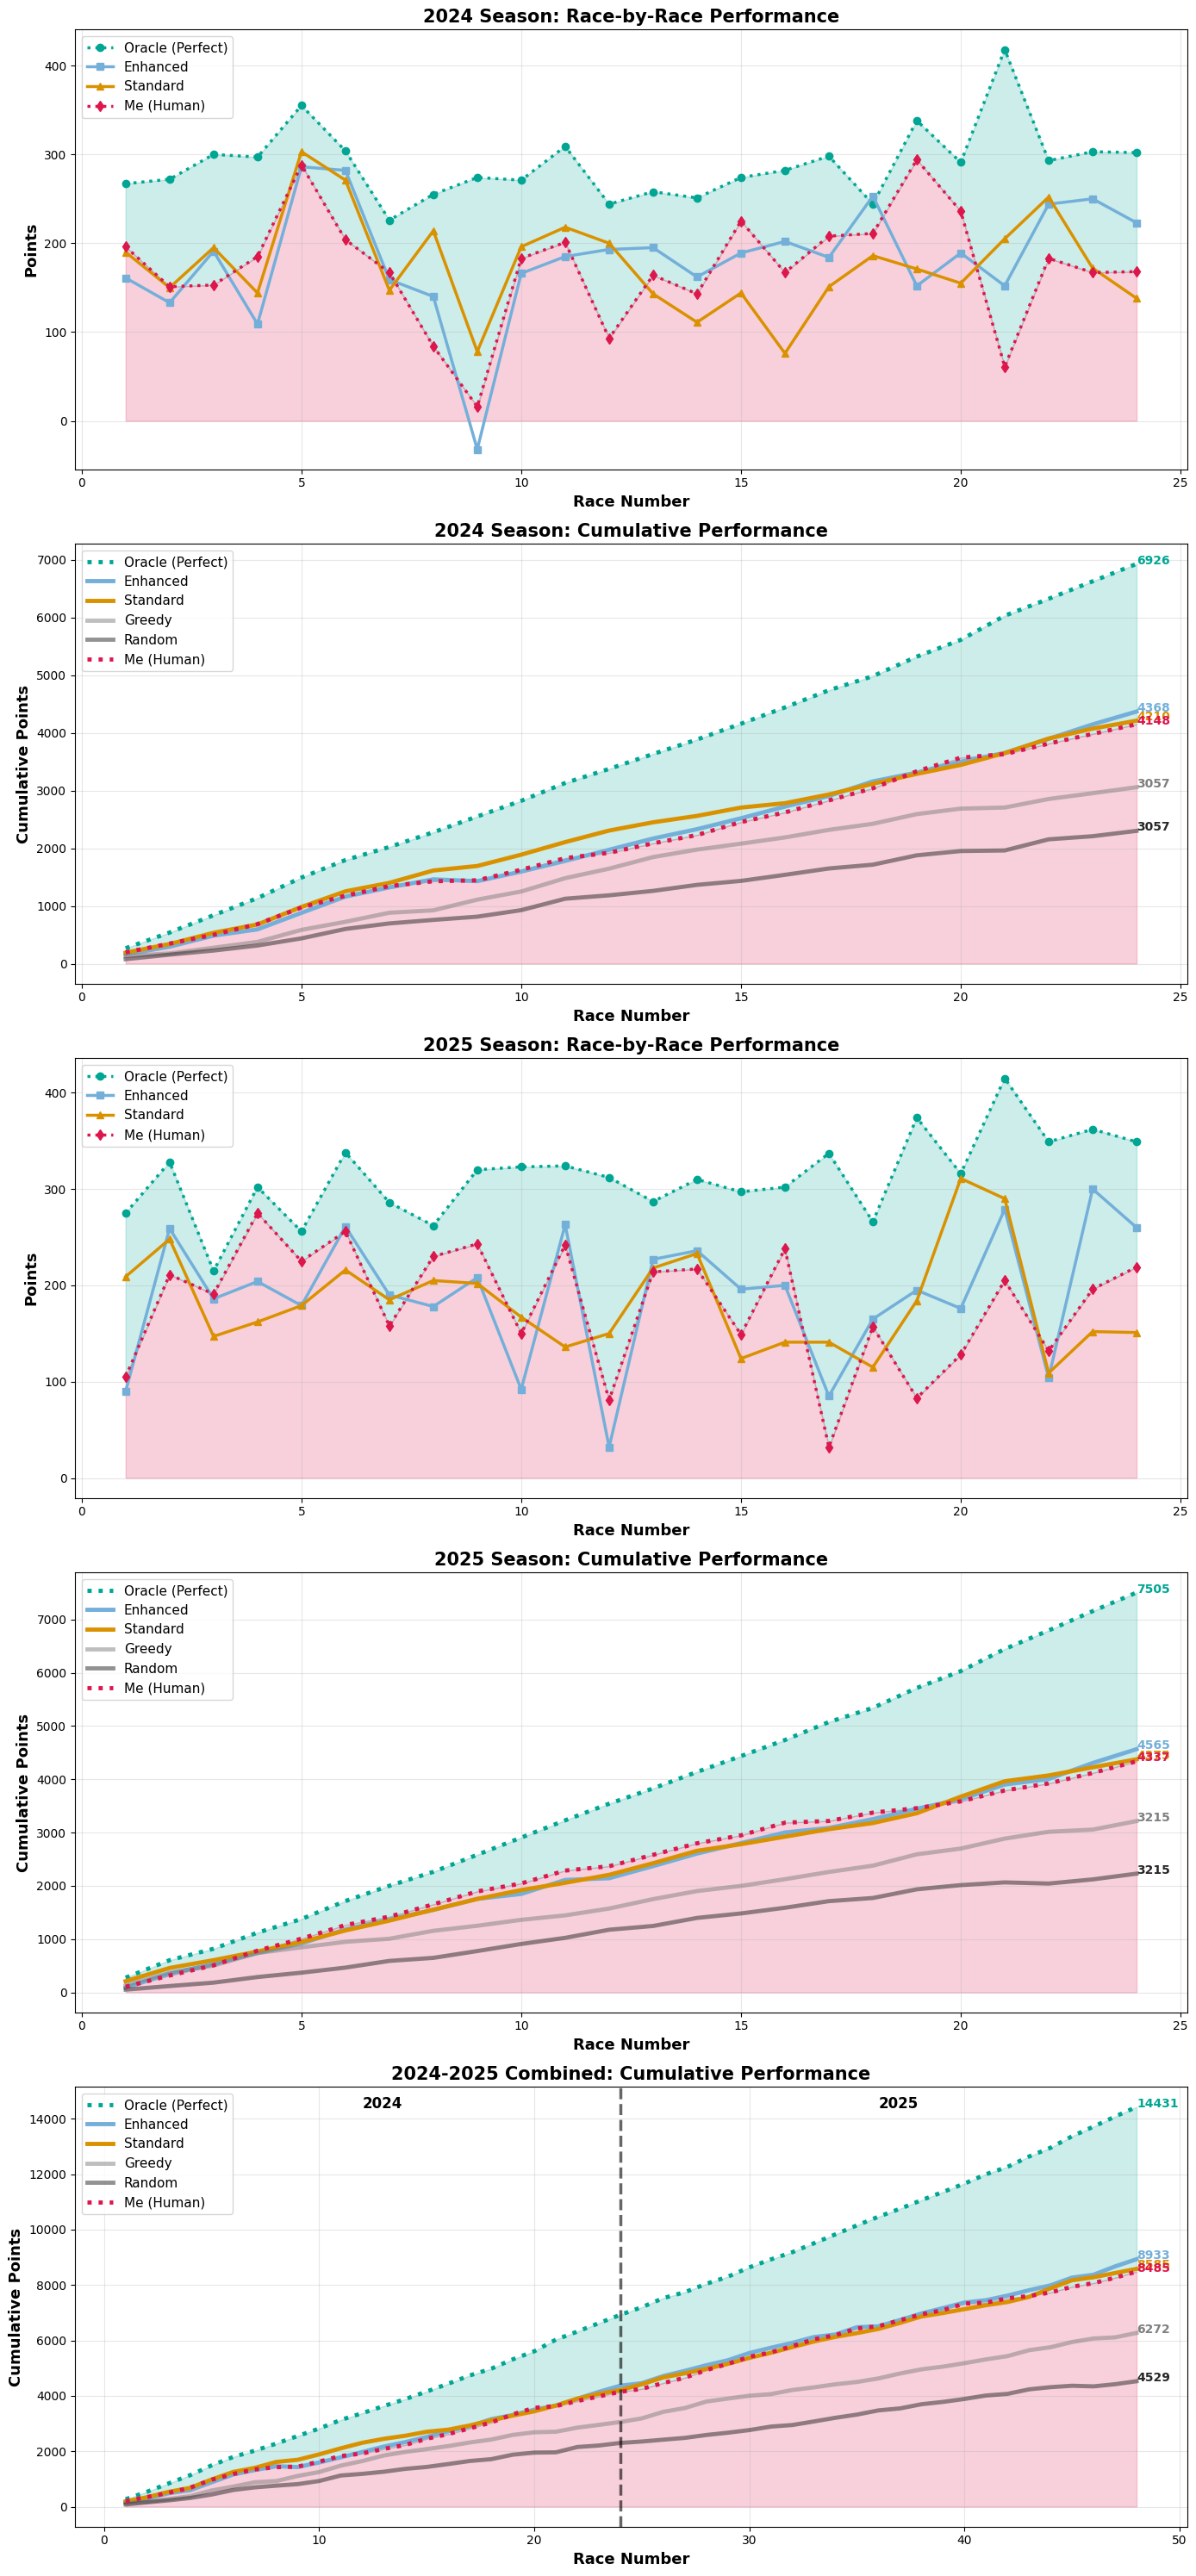

In [ ]:
# Split data by season
comparison_2024 = comparison_full[comparison_full['Season'] == 2024].reset_index(drop=True)
comparison_2025 = comparison_full[comparison_full['Season'] == 2025].reset_index(drop=True)

colors = {
    'Oracle': '#00a693',
    'Enhanced': '#74afda',
    'Standard': '#da9100',
    'Me': '#dd164c',
    'Greedy': '#7f7f7f',
    'Random': '#262626'
}

fig, axes = plt.subplots(5, 1, figsize=(14, 30))

# 2024 Race-by-Race
ax1 = axes[0]
race_nums_2024 = range(1, len(comparison_2024) + 1)

ax1.plot(race_nums_2024, comparison_2024['Oracle_Points'], 'o', linewidth=2.5, linestyle=':',
        label='Oracle (Perfect)', color=colors['Oracle'])
ax1.plot(race_nums_2024, comparison_2024['UpdateAll_Points'], 's-', linewidth=2.5,
        label='Enhanced', color=colors['Enhanced'])
ax1.plot(race_nums_2024, comparison_2024['Bandit_Points'], '^-', linewidth=2.5,
        label='Standard', color=colors['Standard'])
ax1.plot(race_nums_2024, comparison_2024['My_Points'], 'd', linewidth=2.5, linestyle=':',
        label='Me (Human)', color=colors['Me'])

ax1.fill_between(race_nums_2024, comparison_2024['Oracle_Points'], comparison_2024['My_Points'], color=colors['Oracle'], alpha=0.2)
ax1.fill_between(race_nums_2024, comparison_2024['My_Points'], 0, color=colors['Me'], alpha=0.2)

ax1.set_xlabel('Race Number', fontsize=13, fontweight='bold')
ax1.set_ylabel('Points', fontsize=13, fontweight='bold')
ax1.set_title('2024 Season: Race-by-Race Performance', fontsize=15, fontweight='bold')
ax1.legend(fontsize=11)
ax1.grid(True, alpha=0.3)

# 2024 Cumulative
ax2 = axes[1]

ax2.plot(race_nums_2024, comparison_2024['Oracle_Points'].cumsum(), linewidth=3.5, linestyle=':',
        label='Oracle (Perfect)', color=colors['Oracle'])
ax2.plot(race_nums_2024, comparison_2024['UpdateAll_Points'].cumsum(), linewidth=3.5,
        label='Enhanced', color=colors['Enhanced'])
ax2.plot(race_nums_2024, comparison_2024['Bandit_Points'].cumsum(), linewidth=3.5,
        label='Standard', color=colors['Standard'])
ax2.plot(race_nums_2024, comparison_2024['Greedy_Points'].cumsum(), linewidth=3.5,
        label='Greedy', color=colors['Greedy'], alpha=0.5)
ax2.plot(race_nums_2024, comparison_2024['Random_Points'].cumsum(), linewidth=3.5,
        label='Random', color=colors['Random'], alpha=0.5)
ax2.plot(race_nums_2024, comparison_2024['My_Points'].cumsum(), linewidth=3.5, linestyle=':',
        label='Me (Human)', color=colors['Me'])

ax2.fill_between(race_nums_2024, comparison_2024['Oracle_Points'].cumsum(), comparison_2024['My_Points'].cumsum(), color=colors['Oracle'], alpha=0.2)
ax2.fill_between(race_nums_2024, comparison_2024['My_Points'].cumsum(), 0, color=colors['Me'], alpha=0.2)


# Add final totals
final_oracle_2024 = comparison_2024['Oracle_Points'].sum()
final_updateall_2024 = comparison_2024['UpdateAll_Points'].sum()
final_bandit_2024 = comparison_2024['Bandit_Points'].sum()
final_me_2024 = comparison_2024['My_Points'].sum()
final_greedy_2024 = comparison_2024['Greedy_Points'].sum()
final_random_2024 = comparison_2024['Random_Points'].sum()

ax2.text(len(comparison_2024), final_oracle_2024, int(final_oracle_2024),
        fontsize=10, fontweight='bold', color=colors['Oracle'])
ax2.text(len(comparison_2024), final_updateall_2024, int(final_updateall_2024),
        fontsize=10, fontweight='bold', color=colors['Enhanced'])
ax2.text(len(comparison_2024), final_bandit_2024, int(final_bandit_2024),
        fontsize=10, fontweight='bold', color=colors['Standard'])
ax2.text(len(comparison_2024), final_me_2024, int(final_me_2024),
        fontsize=10, fontweight='bold', color=colors['Me'])
ax2.text(len(comparison_2024), final_greedy_2024, int(final_greedy_2024),
        fontsize=10, fontweight='bold', color=colors['Greedy'])
ax2.text(len(comparison_2024), final_random_2024, int(final_greedy_2024),
        fontsize=10, fontweight='bold', color=colors['Random'])

ax2.set_xlabel('Race Number', fontsize=13, fontweight='bold')
ax2.set_ylabel('Cumulative Points', fontsize=13, fontweight='bold')
ax2.set_title('2024 Season: Cumulative Performance', fontsize=15, fontweight='bold')
ax2.legend(fontsize=11)
ax2.grid(True, alpha=0.3)


# 2025 Race-by-Race
ax3 = axes[2]
race_nums_2025 = range(1, len(comparison_2025) + 1)

ax3.plot(race_nums_2025, comparison_2025['Oracle_Points'], 'o', linewidth=2.5, linestyle=':',
        label='Oracle (Perfect)', color=colors['Oracle'])
ax3.plot(race_nums_2025, comparison_2025['UpdateAll_Points'], 's-', linewidth=2.5,
        label='Enhanced', color=colors['Enhanced'])
ax3.plot(race_nums_2025, comparison_2025['Bandit_Points'], '^-', linewidth=2.5,
        label='Standard', color=colors['Standard'])
ax3.plot(race_nums_2025, comparison_2025['My_Points'], 'd', linewidth=2.5, linestyle=':',
        label='Me (Human)', color=colors['Me'])

ax3.fill_between(race_nums_2025, comparison_2025['Oracle_Points'], comparison_2025['My_Points'], color=colors['Oracle'], alpha=0.2)
ax3.fill_between(race_nums_2025, comparison_2025['My_Points'], 0, color=colors['Me'], alpha=0.2)


ax3.set_xlabel('Race Number', fontsize=13, fontweight='bold')
ax3.set_ylabel('Points', fontsize=13, fontweight='bold')
ax3.set_title('2025 Season: Race-by-Race Performance', fontsize=15, fontweight='bold')
ax3.legend(fontsize=11)
ax3.grid(True, alpha=0.3)


# 2025 Cumulative
ax4 = axes[3]

ax4.plot(race_nums_2025, comparison_2025['Oracle_Points'].cumsum(), linewidth=3.5, linestyle=':',
        label='Oracle (Perfect)', color=colors['Oracle'])
ax4.plot(race_nums_2025, comparison_2025['UpdateAll_Points'].cumsum(), linewidth=3.5,
        label='Enhanced', color=colors['Enhanced'])
ax4.plot(race_nums_2025, comparison_2025['Bandit_Points'].cumsum(), linewidth=3.5,
        label='Standard', color=colors['Standard'])
ax4.plot(race_nums_2025, comparison_2025['Greedy_Points'].cumsum(), linewidth=3.5,
        label='Greedy', color=colors['Greedy'], alpha=0.5)
ax4.plot(race_nums_2025, comparison_2025['Random_Points'].cumsum(), linewidth=3.5,
        label='Random', color=colors['Random'], alpha=0.5)
ax4.plot(race_nums_2025, comparison_2025['My_Points'].cumsum(), linewidth=3.5, linestyle=':',
        label='Me (Human)', color=colors['Me'])

ax4.fill_between(race_nums_2025, comparison_2025['Oracle_Points'].cumsum(), comparison_2025['My_Points'].cumsum(), color=colors['Oracle'], alpha=0.2)
ax4.fill_between(race_nums_2025, comparison_2025['My_Points'].cumsum(), 0, color=colors['Me'], alpha=0.2)

# Add final totals
final_oracle_2025 = comparison_2025['Oracle_Points'].sum()
final_updateall_2025 = comparison_2025['UpdateAll_Points'].sum()
final_bandit_2025 = comparison_2025['Bandit_Points'].sum()
final_me_2025 = comparison_2025['My_Points'].sum()
final_greedy_2025 = comparison_2025['Greedy_Points'].sum()
final_random_2025 = comparison_2025['Random_Points'].sum()

ax4.text(len(comparison_2025), final_oracle_2025, int(final_oracle_2025),
        fontsize=10, fontweight='bold', color=colors['Oracle'])
ax4.text(len(comparison_2025), final_updateall_2025, int(final_updateall_2025),
        fontsize=10, fontweight='bold', color=colors['Enhanced'])
ax4.text(len(comparison_2025), final_bandit_2025, int(final_bandit_2025),
        fontsize=10, fontweight='bold', color=colors['Standard'])
ax4.text(len(comparison_2025), final_me_2025, int(final_me_2025),
        fontsize=10, fontweight='bold', color=colors['Me'])
ax4.text(len(comparison_2025), final_greedy_2025, int(final_greedy_2025),
        fontsize=10, fontweight='bold', color=colors['Greedy'])
ax4.text(len(comparison_2025), final_random_2025, int(final_greedy_2025),
        fontsize=10, fontweight='bold', color=colors['Random'])

ax4.set_xlabel('Race Number', fontsize=13, fontweight='bold')
ax4.set_ylabel('Cumulative Points', fontsize=13, fontweight='bold')
ax4.set_title('2025 Season: Cumulative Performance', fontsize=15, fontweight='bold')
ax4.legend(fontsize=11)
ax4.grid(True, alpha=0.3)


# Both Seasons Combined Cumulative
ax5 = axes[4]
race_nums_all = range(1, len(comparison_full) + 1)

ax5.plot(race_nums_all, comparison_full['Oracle_Points'].cumsum(), linewidth=3.5, linestyle=':',
        label='Oracle (Perfect)', color=colors['Oracle'])
ax5.plot(race_nums_all, comparison_full['UpdateAll_Points'].cumsum(), linewidth=3.5,
        label='Enhanced', color=colors['Enhanced'])
ax5.plot(race_nums_all, comparison_full['Bandit_Points'].cumsum(), linewidth=3.5,
        label='Standard', color=colors['Standard'])
ax5.plot(race_nums_all, comparison_full['Greedy_Points'].cumsum(), linewidth=3.5,
        label='Greedy', color=colors['Greedy'], alpha=0.5)
ax5.plot(race_nums_all, comparison_full['Random_Points'].cumsum(), linewidth=3.5,
        label='Random', color=colors['Random'], alpha=0.5)
ax5.plot(race_nums_all, comparison_full['My_Points'].cumsum(), linewidth=3.5, linestyle=':',
        label='Me (Human)', color=colors['Me'])

ax5.fill_between(race_nums_all, comparison_full['Oracle_Points'].cumsum(), comparison_full['My_Points'].cumsum(), color=colors['Oracle'], alpha=0.2)
ax5.fill_between(race_nums_all, comparison_full['My_Points'].cumsum(), 0, color=colors['Me'], alpha=0.2)

# Add season separator
season_split = len(comparison_2024)
ax5.axvline(x=season_split, color='black', linestyle='--', alpha=0.6, linewidth=2.5)
ax5.text(season_split/2, ax5.get_ylim()[1]*0.95, '2024',
        fontsize=12, fontweight='bold')
ax5.text(season_split + (len(comparison_full) - season_split)/2, ax5.get_ylim()[1]*0.95, '2025',
        fontsize=12, fontweight='bold')

# Add final totals
final_oracle_all = comparison_full['Oracle_Points'].sum()
final_updateall_all = comparison_full['UpdateAll_Points'].sum()
final_bandit_all = comparison_full['Bandit_Points'].sum()
final_me_all = comparison_full['My_Points'].sum()
final_greedy_all = comparison_full['Greedy_Points'].sum()
final_random_all = comparison_full['Random_Points'].sum()

ax5.text(len(comparison_full), final_oracle_all, int(final_oracle_all),
        fontsize=10, fontweight='bold', color=colors['Oracle'])
ax5.text(len(comparison_full), final_updateall_all, int(final_updateall_all),
        fontsize=10, fontweight='bold', color=colors['Enhanced'])
ax5.text(len(comparison_full), final_bandit_all, int(final_bandit_all),
        fontsize=10, fontweight='bold', color=colors['Standard'])
ax5.text(len(comparison_full), final_me_all, int(final_me_all),
        fontsize=10, fontweight='bold', color=colors['Me'])
ax5.text(len(comparison_full), final_greedy_all, int(final_greedy_all),
        fontsize=10, fontweight='bold', color=colors['Greedy'])
ax5.text(len(comparison_full), final_random_all, int(final_random_all),
        fontsize=10, fontweight='bold', color=colors['Random'])

ax5.set_xlabel('Race Number', fontsize=13, fontweight='bold')
ax5.set_ylabel('Cumulative Points', fontsize=13, fontweight='bold')
ax5.set_title('2024-2025 Combined: Cumulative Performance', fontsize=15, fontweight='bold')
ax5.legend(fontsize=11)
ax5.grid(True, alpha=0.3)


plt.tight_layout()
plt.show()

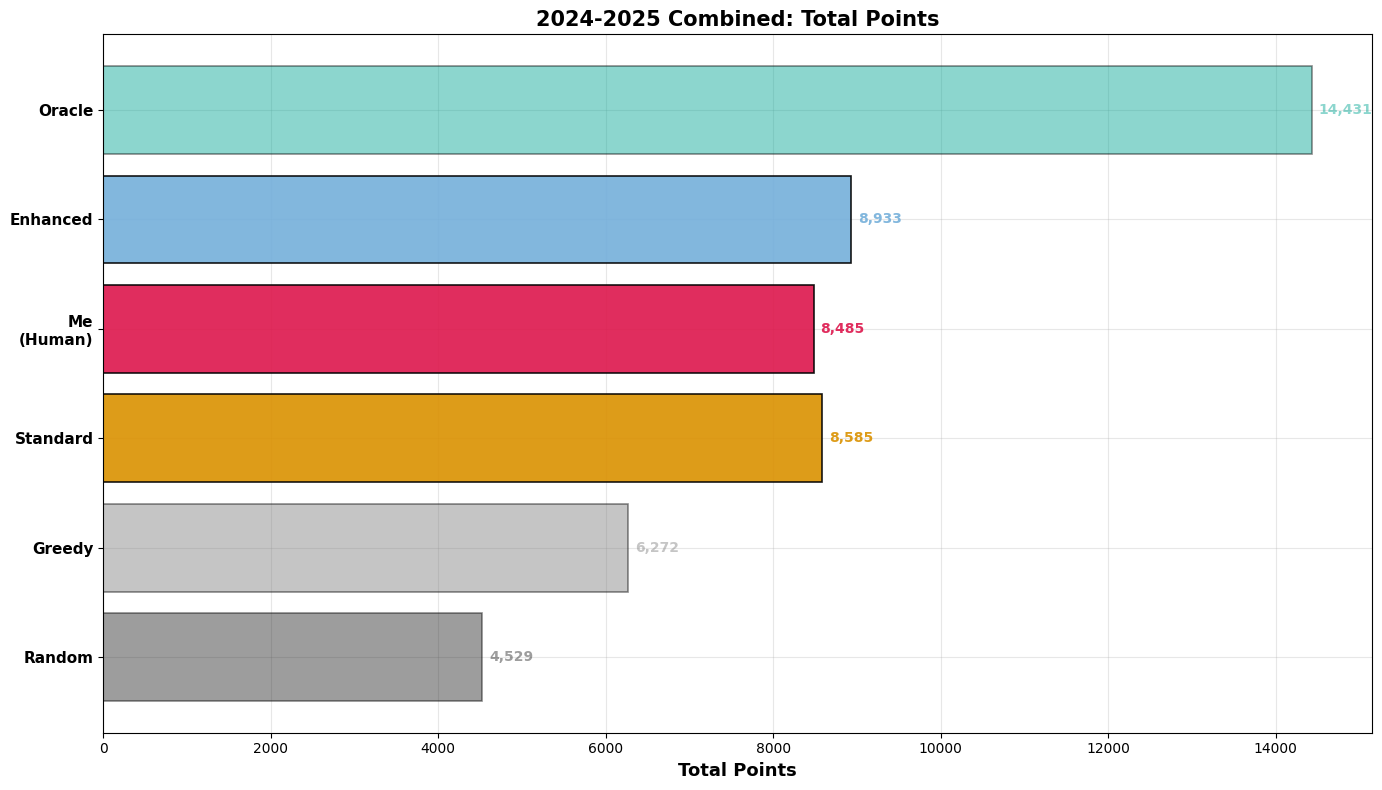

In [ ]:
# Slide 9 Bar Chart - matching your existing chart style
fig_bar, ax_bar = plt.subplots(figsize=(14, 8))

# Data
methods = ['Random', 'Greedy', 'Standard', 'Me\n(Human)', 'Enhanced', 'Oracle']
points_bar = [final_random_all, final_greedy_all, final_bandit_all, final_me_all, final_updateall_all, final_oracle_all, ]

bar_colors_list = [
    colors['Random'],
    colors['Greedy'],
    colors['Standard'],
    colors['Me'],
    colors['Enhanced'],
    colors['Oracle'],
]

# Alphas matching your chart (Greedy and Random at 0.5, others at 1.0)
bar_alphas = [0.45, 0.45, 0.9, 0.9, 0.9, 0.45,]

# Create horizontal bars
y_pos = np.arange(len(methods), )
for i, (y, point, color, alpha) in enumerate(zip(y_pos, points_bar, bar_colors_list, bar_alphas)):
    ax_bar.barh(y, point, color=color, alpha=alpha, edgecolor='black', linewidth=1.2)

# Add value labels on bars
for i, (y, point, color, alpha) in enumerate(zip(y_pos, points_bar, bar_colors_list, bar_alphas)):
    ax_bar.text(point + 80, y, f'{int(point):,}',
                ha='left', va='center', fontsize=10, fontweight='bold',
                color=color, alpha=alpha)

# Formatting matching your chart style
ax_bar.set_yticks(y_pos)
ax_bar.set_yticklabels(methods, fontsize=11, fontweight='bold')
ax_bar.set_xlabel('Total Points', fontsize=13, fontweight='bold')
ax_bar.set_title('2024-2025 Combined: Total Points', fontsize=15, fontweight='bold')

# Grid matching your style
ax_bar.grid(True, alpha=0.3)
ax_bar.set_axisbelow(True)


plt.tight_layout()
plt.savefig('slide9_main_result_bar_chart.png', dpi=300, bbox_inches='tight')
plt.show()

---
# Hyperparameter Tuning